# Rate design v2 — the hedge build

**Who this is for.** This notebook is written to be readable without a
technical background. Every term of art gets a short explanation, in
parentheses, at its first use.

**Why this notebook exists.** The v1 notebook (`rate_design.ipynb`) built
two candidate analyses and put them through a pre-registered adversarial
audit. The audit ruled: Part A (the cost of information) is defensible with
caveats; Part B (the budget-optimal contours) may **not** enter the paper
without repairs, because the model runs certify only scaled copies of one
reference schedule, not schedules of arbitrary shape. Ethan now faces an
NREL review deadline before the Nature submission and can run exactly
**one** batch of ReEDS runs (at most 42 when v2 was registered; raised to
66 by the v2.2 pre-launch amendment of 2026-09-04). This notebook is the
hedge:

- **Part A** restates the v1 information result with every audit repair
  (reporting layer only; the v1 sweep is the input).
- **Part B** is the **zero-run section B**: only claims that existing model
  artifacts certify, denominated in 2024 dollars. This is what goes into
  the paper now.
- **Part C** computes the repaired envelope machinery and emits the
  **run batch** (42 runs at v2.1; 66 at v2.2): exact run specifications,
  pre-registered pass/fail gates, and the ladder of claims each outcome
  buys. The section upgrades only if the runs pass; if they fail, Part B
  stands unchanged.

**The contract.** The v2 section of `methods.md` — every definition,
threshold, selection rule, and kill criterion below — was written and saved
before this notebook's builder existed. The final cell dispositions every
gate and kill into `u91_verdict.csv`. No paper document is edited on this
notebook's basis until the three adversarial audits and Ethan's
ratification.

The six mandate schedules, smallest to largest: eia, aj, iaea, mck, cop28,
eo. Run on the **playground-env** kernel.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sys
sys.path.insert(0, str(Path.cwd().parent))
import plotstyle as ps

ps.apply()
pd.set_option("display.width", 220)

HERE = Path.cwd()
assert HERE.name == "rate_design", f"run from z-ethan/rate_design/, not {HERE}"
REPO = HERE.parents[1]
EXPORTS = HERE / "exports"
FIGURES = HERE / "figures"
EXPORTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

MC_EXPORTS = REPO / "z-ethan" / "mc" / "exports"
CHECKS3 = REPO / "z-ethan" / "step3_checks" / "exports"
S3ANALYSIS = REPO / "z-ethan" / "step3_analysis" / "exports"
ITCFBM = REPO / "z-ethan" / "itcfbm_analysis" / "exports"
BRIDGE = REPO / "z-ethan" / "bridge_detection" / "exports"

SEED = 20260901
TOL_SHORT = 0.01          # delivery cushion, statutory rate points (r03-certified)
LV_MID = (0.30, 0.10)     # the stage-3 mid-noise headline dials
LV_LIGHT = (0.15, 0.05)
UNIT_MW = 300
BUDGET_MULTS = [0.75, 1.0, 1.25, 1.5, 2.0]   # reported contour budgets, x p50 bill
FB_MULTS = [1.0, 1.5]     # the batch's envelope budgets (methods.md v2)
CAPS = [0.50, 0.60]       # statutory-ceiling levels (0.50 = today's max)
W_PRIMARY = 2035          # demonstration window: build years through 2035
W_SENS = 2033             # window sensitivity
ESS_FLOOR = 100.0
ASYMPTOTE_SLOPE = 0.05    # avg decline per obs over last 3 obs, below = asymptote
RATE_SCREEN = 0.95        # a run world must keep every offered rate <= this
VERDICT = []              # (kind, name, result, detail) rows -> u91

# ---- the MC ensemble --------------------------------------------------------------
Z = np.load(MC_EXPORTS / "mc_perdraw.npz")
META = json.loads(str(Z["meta_json"]))
assert META["n_draws"] == 10000 and META["master_seed"] == 20260715, META
YI = {int(y): i for i, y in enumerate(Z["years"])}

SCHEDULES = ["eia", "aj", "iaea", "mck", "cop28", "eo"]  # ambition order
AB2TOK = {"eia": "eia_aeo_high", "aj": "abou_jaoude", "iaea": "iaea_high",
          "mck": "mckinsey", "cop28": "cop28", "eo": "eo2025"}
TOK2AB = {v: k for k, v in AB2TOK.items()}
NAME2AB = {str(n): TOK2AB[str(t)] for n, t in zip(Z["sched_order"], Z["scen_tokens"])}
WCOLS = [str(c) for c in Z["world_columns"]]
LR_SMR = {ab: Z[f"worlds_{AB2TOK[ab]}"][:, WCOLS.index("lr_smr")] for ab in SCHEDULES}

reg_smr = pd.read_csv(MC_EXPORTS / "smr100" / "selected_draws.csv")
reg_smr["ab"] = reg_smr["schedule"].map(NAME2AB)
assert len(reg_smr) == 18 and reg_smr["ab"].notna().all()
ANCH = {ab: {} for ab in SCHEDULES}
for _, r in reg_smr.iterrows():
    ANCH[r["ab"]][r["percentile"]] = int(r["draw_index"])

# ---- discount rate and price level (must reproduce the study constants) -----------
FIN_DIR = REPO / "inputs" / "financials"
sys_fin = pd.read_csv(FIN_DIR / "financials_sys_ATB2024.csv")
infl = pd.read_csv(FIN_DIR / "inflation_default.csv")
sys_fin = sys_fin.merge(infl, on="t", how="left")
sys_fin["d_nom"] = ((1 - sys_fin["debt_fraction"]) * (sys_fin["rroe_nom"] - 1)
                    + sys_fin["debt_fraction"] * (sys_fin["interest_rate_nom"] - 1)
                      * (1 - sys_fin["tax_rate"]) + 1)
sys_fin["d_real"] = sys_fin["d_nom"] / sys_fin["inflation_rate"]
_s = sys_fin.set_index("t")["d_real"].reindex(range(1990, 2051)).ffill()
DR = float(np.mean(_s.loc[np.arange(2010, 2051)].to_numpy(float)))
assert round(DR, 4) == 1.0455, DR
_infl = infl.set_index("t")["inflation_rate"]
D2224 = float(_infl.loc[2023] * _infl.loc[2024])
assert 1.0 < D2224 < 1.2, D2224

# ---- mandate additions ------------------------------------------------------------
duals3 = pd.read_csv(CHECKS3 / "duals_by_year.csv")
FLOOR = duals3[duals3["t"] <= 2030].groupby("case")["mandate_MW"].max()
duals3["program_MW"] = (duals3["mandate_MW"]
                        - duals3["case"].map(FLOOR).fillna(0.0)).clip(lower=0.0)
DCASE = {c: g.set_index("t") for c, g in duals3.groupby("case")}

# ---- published tables -------------------------------------------------------------
t08 = pd.read_csv(S3ANALYSIS / "t08_rental_transfer.csv").set_index("case")
t09 = pd.read_csv(S3ANALYSIS / "t09_required_itc.csv")
t09r = t09[t09["status"] == "rate"].set_index(["case", "t"])["i_model_headline"]
t12 = pd.read_csv(S3ANALYSIS / "t12_fiscal_comparison.csv").set_index("case")

def rate_of(case, t):
    v = t09r.get((case, t), 0.0)
    return float(v) if np.isfinite(v) else 0.0

# censored anchor year-cells: t09 encodes censoring as the BOOLEAN column
# itc_insufficient on rows whose status is still "rate" (the recorded rate,
# >= 1.0, is a lower bound — the model said no credit under 100% suffices).
# The v2.0 filter matched status text and flagged nothing (audit B finding 1).
cens = (t09[t09["itc_insufficient"].fillna(False).astype(bool)]
        if "itc_insufficient" in t09.columns else t09.iloc[0:0])
CENSORED = set()
for _, r in cens.iterrows():
    parts = str(r["case"]).split("_")
    if len(parts) >= 3 and parts[0] == "smr100":
        CENSORED.add(("_".join(parts[1:-1]), int(r["t"])))
print("censored anchor year-cells (schedule, year):", sorted(CENSORED))

# ---- per-world bills + gate G0 ----------------------------------------------------
BW = np.load(BRIDGE / "b07_bills_perworld.npz")
BILL_YEARS = [int(y) for y in BW["obs_years"]]
B2050 = {ab: BW[f"b2050_{ab}"] for ab in SCHEDULES}
g0_fail = []
for ab in SCHEDULES:
    for p in ["p05", "p50", "p95"]:
        pub = float(t08.loc[f"smr100_{ab}_{p}", "PV_rental_transfer_2024B"])
        if abs(B2050[ab][ANCH[ab][p]] - pub) > 0.051:
            g0_fail.append((ab, p))
G0 = not g0_fail
assert G0, g0_fail
P50BILL = {ab: float(t08.loc[f"smr100_{ab}_p50", "PV_rental_transfer_2024B"])
           for ab in SCHEDULES}
VERDICT.append(("gate", "G0", "PASS",
                "b07 per-world bills reproduce published t08 at all 18 anchors (<=0.051 $B)"))
print("G0 PASS; p50 bills (2024 $B):", {k: round(v, 1) for k, v in P50BILL.items()})


censored anchor year-cells (schedule, year): [('cop28', 2050), ('eo', 2047), ('eo', 2050)]
G0 PASS; p50 bills (2024 $B): {'eia': 31.1, 'aj': 32.7, 'iaea': 91.8, 'mck': 116.3, 'cop28': 190.8, 'eo': 331.9}


## S1 — shared machinery (v1-identical, gates re-asserted)

Only the 3 anchor worlds per schedule carry model-computed required rates
(t09). Every other world's rate is interpolated per build year: the three
anchor points (that year's build cost against that year's required rate)
are connected with straight line segments, and a world's rate is read off
at its own build cost, held flat outside the outer anchors. From the
interpolated rates, with the one-point cushion the model runs certify
(r03): **need_w(t)** = (required rate − 0.01) × the world's own build cost
(2024 $/kW), and **f\*_w** = the smallest scale on the reference (the p50
anchor's declared $/kW path) that covers need_w in every build year. Outlay
pricing is fixed-basis: PV = kappa × Σ offer(t) × additions(t) ×
discount(t), kappa calibrated to the published t12 outlays.

This cell re-asserts G1 (interpolation exact at all 18 anchors + the p50
calibration identity), G2 (the reference equals what the feed-back runs
fed; the r03 bracket unchanged), G3 (calibration residual ≤ 7%), and the
match to the stored instrument_comparison `s01` thresholds.

In [2]:
ADD, DISC, BUILD_TS = {}, {}, {}
IREF, IW, OCCW, NEED = {}, {}, {}, {}
REFC, FSTAR, COVER, BINDY = {}, {}, {}, {}
KAPPA, KAP_RES, SPREF, IBAR, WPRICE = {}, {}, {}, {}, {}
TOPKNOT_PCT, BOTKNOT_PCT, UPCLAMP = {}, {}, {}
g1_fail = []

for ab in SCHEDULES:
    d0 = DCASE[f"smr100_{ab}_p05"]
    build_ts = [int(t) for t in d0.index if t >= 2026 and d0.loc[t, "program_MW"] > 0]
    prog = np.array([d0.loc[t, "program_MW"] for t in build_ts])
    add = np.diff(prog, prepend=0.0).clip(min=0.0)
    disc = np.array([DR ** -(t - 2026) for t in build_ts])
    keep = add > 0
    BUILD_TS[ab] = [t for t, k in zip(build_ts, keep) if k]
    ADD[ab] = add[keep]
    DISC[ab] = disc[keep]

    occ = Z[f"occ_{AB2TOK[ab]}_smr"]
    occ_t = np.stack([occ[:, YI[t]] for t in BUILD_TS[ab]], axis=1)  # 2022 $/kW
    OCCW[ab] = occ_t * D2224                                        # 2024 $/kW
    cases = {p: f"smr100_{ab}_{p}" for p in ["p05", "p50", "p95"]}

    iw = np.empty_like(occ_t)
    topknot = np.empty(len(BUILD_TS[ab]))
    botknot = np.empty(len(BUILD_TS[ab]))
    for j, t in enumerate(BUILD_TS[ab]):
        xs = np.array([occ[ANCH[ab][p], YI[t]] for p in ["p05", "p50", "p95"]])
        ys = np.array([rate_of(cases[p], t) for p in ["p05", "p50", "p95"]])
        o = np.argsort(xs)
        xs, ys = xs[o], ys[o]
        assert np.all(np.diff(xs) > 0), (ab, t, xs)
        iw[:, j] = np.interp(occ_t[:, j], xs, ys)
        topknot[j] = xs[-1]
        botknot[j] = xs[0]
    IW[ab] = iw
    IREF[ab] = np.array([rate_of(cases["p50"], t) for t in BUILD_TS[ab]])
    TOPKNOT_PCT[ab] = np.array([float((occ_t[:, j] <= topknot[j]).mean())
                                for j in range(len(BUILD_TS[ab]))])
    BOTKNOT_PCT[ab] = np.array([float((occ_t[:, j] < botknot[j]).mean())
                                for j in range(len(BUILD_TS[ab]))])
    UPCLAMP[ab] = np.any(occ_t > topknot[None, :], axis=1)

    for p in ["p05", "p50", "p95"]:
        w_ = ANCH[ab][p]
        tru = np.array([rate_of(cases[p], t) for t in BUILD_TS[ab]])
        if np.max(np.abs(iw[w_] - tru)) > 1e-9:
            g1_fail.append((ab, p, "anchor rate identity"))

    need_rate = np.maximum(iw - TOL_SHORT, 0.0)
    NEED[ab] = need_rate * OCCW[ab]                       # 2024 $/kW per year
    occ_ref = OCCW[ab][ANCH[ab]["p50"]]
    REFC[ab] = IREF[ab] * occ_ref                          # reference $/kW path
    with np.errstate(divide="ignore", invalid="ignore"):
        f_ratio = np.where(NEED[ab] > 0,
                           NEED[ab] / np.where(REFC[ab] > 0, REFC[ab], np.nan)[None, :],
                           0.0)
    uncov = np.any((NEED[ab] > 0) & (REFC[ab][None, :] <= 0), axis=1)
    COVER[ab] = ~uncov
    FSTAR[ab] = np.where(uncov, np.inf,
                         np.nanmax(np.where(NEED[ab] > 0, f_ratio, 0.0),
                                   axis=1, initial=0.0))
    BINDY[ab] = np.array(BUILD_TS[ab])[
        np.nanargmax(np.where(NEED[ab] > 0, f_ratio, -1.0), axis=1)]

    w50 = ANCH[ab]["p50"]
    exp50 = float(np.max(np.maximum(IREF[ab] - TOL_SHORT, 0.0)
                         / np.where(IREF[ab] > 0, IREF[ab], np.inf)))
    if abs(FSTAR[ab][w50] - exp50) > 1e-9:
        g1_fail.append((ab, "p50", "calibration-point identity"))

    raw_own = {}
    for p in ["p05", "p50", "p95"]:
        w_ = ANCH[ab][p]
        i_own = np.array([rate_of(cases[p], t) for t in BUILD_TS[ab]])
        raw_own[p] = float(np.sum(i_own * OCCW[ab][w_] * ADD[ab] * DISC[ab]) * 1000 / 1e9)
    pub = {p: float(t12.loc[cases[p], "PV_ITC_outlay_2024B"]) for p in ["p05", "p50", "p95"]}
    KAPPA[ab] = float(np.mean([pub[p] / raw_own[p] for p in ["p05", "p50", "p95"]]))
    KAP_RES[ab] = max(abs(KAPPA[ab] * raw_own[p] / pub[p] - 1) for p in ["p05", "p50", "p95"])
    WPRICE[ab] = KAPPA[ab] * ADD[ab] * DISC[ab] * 1000 / 1e9   # $B per ($/kW offered)
    SPREF[ab] = float(REFC[ab] @ WPRICE[ab])
    wgt_val = occ_ref * ADD[ab] * DISC[ab]
    IBAR[ab] = float(np.sum(IREF[ab] * wgt_val) / wgt_val.sum())

G1 = not g1_fail
assert G1, g1_fail
VERDICT.append(("gate", "G1", "PASS",
                "interpolation exact at all 18 anchors; p50 f* at the calibration point"))
G3 = all(KAP_RES[ab] <= 0.07 for ab in SCHEDULES)
assert G3, {ab: round(KAP_RES[ab], 3) for ab in SCHEDULES}
VERDICT.append(("gate", "G3", "PASS",
                "outlay calibration residual <= 7% at all 18 anchors"))
assert all(COVER[ab].all() for ab in SCHEDULES), "uncoverable worlds appeared"

r01 = pd.read_csv(ITCFBM / "r01_rate_ladder.csv")
r03 = pd.read_csv(ITCFBM / "r03_minimality_verdicts.csv")
heads = r01.drop_duplicates(["world", "t"]).set_index(["world", "t"])["i_head"]
g2_fail = []
for ab in ["aj", "mck", "eo"]:
    ts = sorted(set(heads.loc[ab].index) & set(BUILD_TS[ab]))
    diff = max(abs(float(heads.loc[(ab, t)]) - rate_of(f"smr100_{ab}_p50", t)) for t in ts)
    if diff > 1e-6:
        g2_fail.append((ab, round(diff, 6)))
if not (set(r03["deepest_delivering_rung"]) == {"m01"}
        and set(r03["shallowest_failing_rung"]) == {"m05"}):
    g2_fail.append(("r03", "bracket changed"))
G2 = not g2_fail
assert G2, g2_fail
VERDICT.append(("gate", "G2", "PASS",
                "reference = fed r01 headline (<=1e-6, aj/mck/eo); r03 bracket (head-5, head-1]"))

s01_old = pd.read_csv(REPO / "z-ethan" / "instrument_comparison" / "exports"
                      / "s01_per_world_thresholds.csv")
for ab in SCHEDULES:
    ref = s01_old[s01_old["schedule"] == ab].sort_values("world")["fstar"].to_numpy()
    assert np.allclose(np.round(FSTAR[ab], 4), ref, atol=5e-4), ab
print("G1/G2/G3 PASS; f* matches the stored s01 export in all six schedules")

# the outlay-vs-bill unit wedge (v1 audit finding 5) — stated on every exhibit
WEDGE = {ab: SPREF[ab] / P50BILL[ab] for ab in SCHEDULES}
print("unit wedge SPREF/P50BILL:", {k: round(v, 2) for k, v in WEDGE.items()})


G1/G2/G3 PASS; f* matches the stored s01 export in all six schedules
unit wedge SPREF/P50BILL: {'eia': 1.85, 'aj': 2.61, 'iaea': 2.0, 'mck': 1.96, 'cop28': 2.19, 'eo': 1.89}


## S2 — Part A restated: the cost of information (v1 result, audit repairs)

The v1 sweep is the input; nothing is recomputed. The v1 result: an
observer watching noisy construction costs **never** narrows the required-
support estimate to the band-5 confidence target (the r03-certified 5-rate-
point band, in scale units) within the program horizon, at any of the three
noise levels, in any of the six schedules. The audit confirmed the result
robust (it holds even at the 25th-percentile-optimistic width under light
noise) and identified the shared industry shock as the floor the per-year
learning-rate information cannot beat.

Registered restatement rules (methods.md v2):

- the cushion-1 target is **retired**;
- "asymptote" is claimed only where the mid-noise median CI declines on
  average ≤ 5% per observation over the last three observations; every
  other schedule is "still declining at the horizon";
- ESS-starved regions (q10 ESS below the 100-world floor) are shaded;
- u13 is a plumbing check; the CIs are CIs on the interpolated proxy, and
  the ±20% map error only strengthens the never-reaches-target finding;
- both failed v1 predictions and the vacuous K5/K6 are dispositioned in
  the verdict, not silently dropped.

In [3]:
u10 = pd.read_csv(EXPORTS / "u10_ci_curves.csv")
u11 = pd.read_csv(EXPORTS / "u11_price_of_information.csv")
u12 = pd.read_csv(EXPORTS / "u12_ess.csv")
u90 = pd.read_csv(EXPORTS / "u90_verdict.csv")

# the v1 Part A gates must be on record as PASS (the sweep is our input)
g4a_row = u90[(u90["name"] == "G4a") & (u90["result"] == "PASS")]
g4b_row = u90[(u90["name"] == "G4b")]
assert len(g4a_row) == 1 and len(g4b_row) == 1, "v1 G4 rows missing"
VERDICT.append(("gate", "G4a/G4b", "PASS-BY-REFERENCE",
                "v1 u90 records G4a PASS (weight identity) and G4b reported; "
                "the v1 sweep is the Part A input, not recomputed"))

TGT5 = {ab: 0.05 / IBAR[ab] for ab in SCHEDULES}

rows30, rows31 = [], []
for ab in SCHEDULES:
    mid = u10[(u10["schedule"] == ab) & (u10["sigma"] == LV_MID[0])
              & (u10["tau"] == LV_MID[1]) & (u10["k"] > 0)].sort_values("k")
    light = u10[(u10["schedule"] == ab) & (u10["sigma"] == LV_LIGHT[0])
                & (u10["tau"] == LV_LIGHT[1]) & (u10["k"] > 0)].sort_values("k")
    prior = u10[(u10["schedule"] == ab) & (u10["sigma"] == LV_MID[0])
                & (u10["tau"] == LV_MID[1]) & (u10["k"] == 0)].iloc[0]
    tr = mid["fstar_w_med"].to_numpy(float)
    # per-step declines over the last three observations
    steps = (tr[:-1] - tr[1:]) / np.maximum(tr[:-1], 1e-9)
    last3 = steps[-3:] if len(steps) >= 3 else steps
    decline = float(np.mean(last3)) if len(last3) else 0.0
    label = "asymptote" if decline <= ASYMPTOTE_SLOPE else "still declining"
    for j, (k_, y_, w_, s_) in enumerate(zip(mid["k"], mid["year"],
                                             mid["fstar_w_med"], mid["spend_med"])):
        rows31.append(dict(schedule=ab, sigma=LV_MID[0], tau=LV_MID[1],
                           k=int(k_), year=int(y_),
                           fstar_w_med=float(w_), spend_med=float(s_),
                           step_decline=float(steps[j - 1]) if j > 0 else np.nan))
    cross = u11[(u11["schedule"] == ab) & (u11["sigma"] == LV_MID[0])
                & (u11["target"] == "band5")].iloc[0]
    q25_light_min = float(light["fstar_w_q25"].min())
    ess_final = u12[(u12["schedule"] == ab) & (u12["sigma"] == LV_MID[0])].iloc[-1]
    rows30.append(dict(
        schedule=ab,
        tgt5_scale=round(TGT5[ab], 4),
        prior_fstar_w=round(float(prior["fstar_w_med"]), 3),
        final_fstar_w_med=round(float(tr[-1]), 3),
        final_over_tgt=round(float(tr[-1] / TGT5[ab]), 1),
        q25_light_over_tgt=round(q25_light_min / TGT5[ab], 1),
        final_lr_w_pts=round(float(mid["lr_w_med"].iloc[-1]) * 100, 1),
        prior_lr_w_pts=round(float(prior["lr_w_med"]) * 100, 1),
        decline_pct_per_obs_last3=round(decline * 100, 1),
        label=label,
        crosses_band5=bool(int(cross["year"]) > 0),
        ess_med_final=float(ess_final["ess_med"]),
        ess_q10_final=float(ess_final["ess_q10"]),
    ))
u30 = pd.DataFrame(rows30)
u30.to_csv(EXPORTS / "u30_part_a_restated.csv", index=False)
u31 = pd.DataFrame(rows31)
u31.to_csv(EXPORTS / "u31_part_a_slopes.csv", index=False)

assert not u30["crosses_band5"].any(), "a schedule crosses band-5: restatement is stale"
n_asym = int((u30["label"] == "asymptote").sum())
ratlo = float(u30["final_over_tgt"].min())
rathi = float(u30["final_over_tgt"].max())
CORS = {ab: float(np.corrcoef(FSTAR[ab], LR_SMR[ab])[0, 1]) for ab in SCHEDULES}
c_least, c_most = max(CORS.values()), min(CORS.values())
VERDICT.append(("parta", "headline", "STANDS",
                "no schedule reaches the band-5 target within the program horizon "
                f"(0/6 cross at any noise level; mid-noise final width "
                f"{ratlo:.1f}-{rathi:.1f}x the target); {n_asym}/6 "
                "earn the asymptote label under the registered <=5%/obs rule"))
VERDICT.append(("partb-pred", "P1-aj-dip", "FAILED",
                "v1 registered Part B prediction failed: the aj contour keeps the "
                "2032 dip (proportionally deeper at low budgets), it does not lift it"))
VERDICT.append(("partb-pred", "P2-mck-control", "FAILED",
                "v1 registered Part B prediction failed: mck is not the smallest-gain "
                "control (ranks 4th-5th of 6; eia/iaea gain least). Superseding "
                "mechanism: requirements are front-loaded per-$/kW while additions "
                "are back-loaded, so early generosity is cheap and buys the "
                f"fast-learning worlds (corr(f*, LR) {c_least:.2f} to {c_most:.2f}, "
                "Pearson, all six schedules, 10,000 worlds)"))
VERDICT.append(("parta", "K5/K6", "N/A-NO-CROSSING",
                "no band-5 crossing ever occurs, so the ESS-at-crossing and "
                "replication-stability criteria have nothing to test"))
VERDICT.append(("parta", "K7", "PASS-BY-REFERENCE",
                "v1 u90: no median-CI widening > 10% between consecutive "
                "observations at any noise level"))
VERDICT.append(("parta", "light-noise-ESS", "DISCLOSE",
                "q25_light_over_tgt is read at 2050, where light-noise q10 ESS is "
                "48-88 for eo/cop28/mck — below the figure's 100-world shading "
                "floor, above the registered K5 median floor; ESS thinning biases "
                "widths narrower, i.e. against the never-crosses headline"))
print(u30.to_string(index=False))


schedule  tgt5_scale  prior_fstar_w  final_fstar_w_med  final_over_tgt  q25_light_over_tgt  final_lr_w_pts  prior_lr_w_pts  decline_pct_per_obs_last3           label  crosses_band5  ess_med_final  ess_q10_final
     eia      0.0756          1.612              0.424             5.6                 2.5             9.3            11.7                        7.5 still declining          False         2589.7         1357.3
      aj      0.0776          1.344              0.599             7.7                 3.1             8.3            11.7                        2.9       asymptote          False         1520.9          681.6
    iaea      0.0705          2.132              0.359             5.1                 2.1             6.2            11.7                       14.3 still declining          False          822.7          354.0
     mck      0.0742          1.731              0.353             4.8                 2.3             5.7            11.7                        7.6 still 

saved -> figures\w20_ci_curves_restated.png


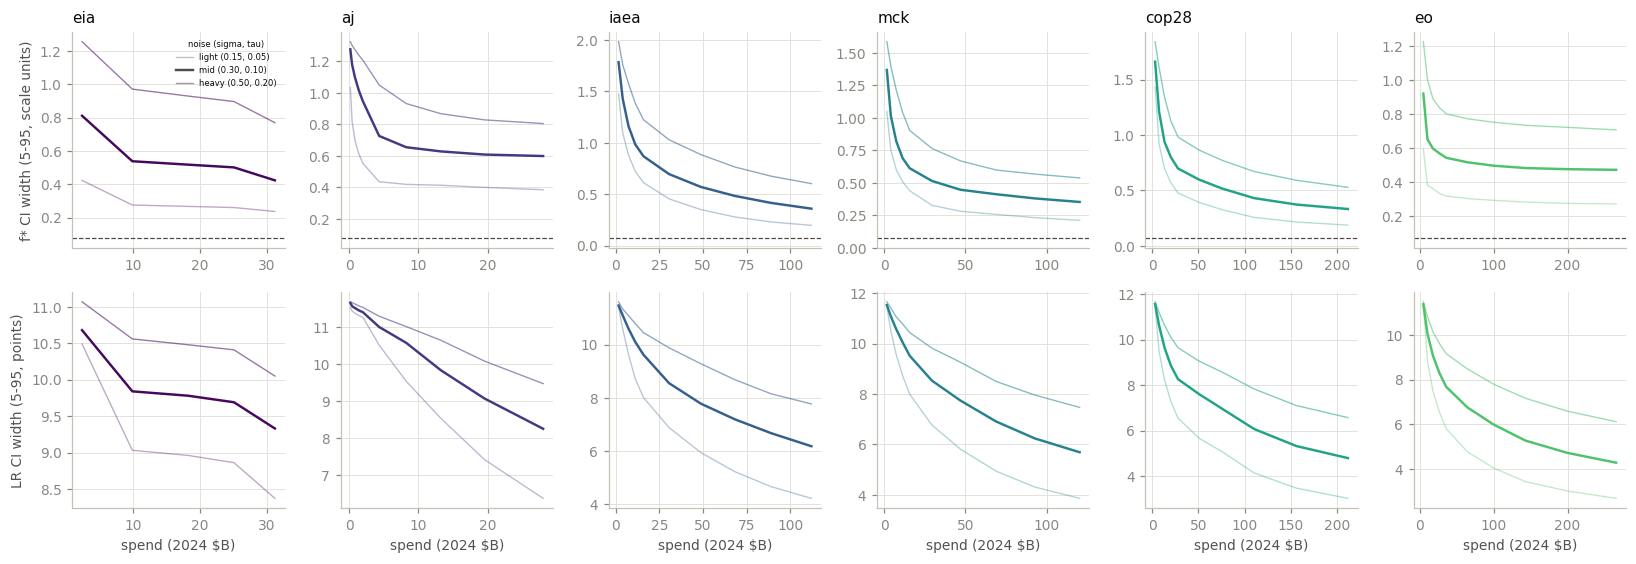

saved -> figures\w21_asymptote.png


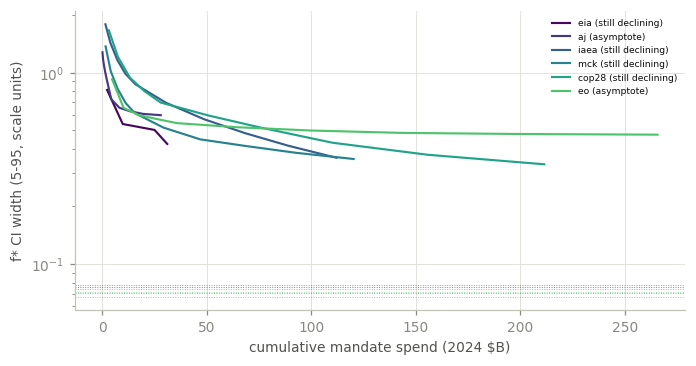

In [4]:
# w20: the restated co-headline CI curves (band-5 target only, ESS shading)
fig, axes = plt.subplots(2, 6, figsize=(ps.W3 * 1.15, 5.2))
LEVELS = [(0.15, 0.05), (0.30, 0.10), (0.50, 0.20)]
LVC = {LEVELS[0]: 0.35, LEVELS[1]: 1.0, LEVELS[2]: 0.55}
for ci, ab in enumerate(SCHEDULES):
    for lv in LEVELS:
        sub = u10[(u10["schedule"] == ab) & (u10["sigma"] == lv[0])
                  & (u10["tau"] == lv[1]) & (u10["k"] > 0)]
        lw = 1.6 if lv == LV_MID else 0.9
        al = LVC[lv]
        axes[0, ci].plot(sub["spend_med"], sub["fstar_w_med"],
                         color=ps.SCHED_C[ab], lw=lw, alpha=al)
        axes[1, ci].plot(sub["spend_med"], sub["lr_w_med"] * 100,
                         color=ps.SCHED_C[ab], lw=lw, alpha=al)
    axes[0, ci].axhline(TGT5[ab], color=ps.BASE_C, lw=0.8, ls="--")
    # ESS shading: from the first mid-noise year whose q10 ESS < floor
    e = u12[(u12["schedule"] == ab) & (u12["sigma"] == LV_MID[0])].sort_values("year")
    m = u10[(u10["schedule"] == ab) & (u10["sigma"] == LV_MID[0])
            & (u10["tau"] == LV_MID[1]) & (u10["k"] > 0)].sort_values("year")
    starved = e[e["ess_q10"] < ESS_FLOOR]
    if len(starved):
        y0 = int(starved["year"].iloc[0])
        s0 = float(m[m["year"] >= y0]["spend_med"].iloc[0])
        for ax in (axes[0, ci], axes[1, ci]):
            ax.axvspan(s0, float(m["spend_med"].iloc[-1]), color="0.85", zorder=0)
    axes[0, ci].set_title(ab)
    axes[1, ci].set_xlabel("spend (2024 $B)")
axes[0, 0].set_ylabel("f* CI width (5-95, scale units)")
axes[1, 0].set_ylabel("LR CI width (5-95, points)")
from matplotlib.lines import Line2D
axes[0, 0].legend(handles=[
    Line2D([], [], color="0.3", lw=0.9, alpha=0.35, label="light (0.15, 0.05)"),
    Line2D([], [], color="0.3", lw=1.6, label="mid (0.30, 0.10)"),
    Line2D([], [], color="0.3", lw=0.9, alpha=0.55, label="heavy (0.50, 0.20)")],
    fontsize=5.5, frameon=False, loc="upper right", title="noise (sigma, tau)",
    title_fontsize=5.5)
fig.tight_layout()
ps.savefig(fig, FIGURES / "w20_ci_curves_restated.png")
plt.show()

# w21: the asymptote presentation — mid-noise f* width vs the target
fig, ax = plt.subplots(figsize=(ps.W1, 3.4))
for ab in SCHEDULES:
    sub = u31[u31["schedule"] == ab]
    ax.plot(sub["spend_med"], sub["fstar_w_med"], color=ps.SCHED_C[ab], lw=1.4,
            label=f"{ab} ({u30.set_index('schedule').loc[ab, 'label']})")
    ax.axhline(TGT5[ab], color=ps.SCHED_C[ab], lw=0.6, ls=":", alpha=0.6)
ax.set_yscale("log")
ax.set_xlabel("cumulative mandate spend (2024 $B)")
ax.set_ylabel("f* CI width (5-95, scale units)")
ax.legend(fontsize=6, frameon=False)
fig.tight_layout()
ps.savefig(fig, FIGURES / "w21_asymptote.png")
plt.show()


## S3 — Part B: the zero-run section (2024 dollars throughout)

Everything in this part is certified by artifacts that already exist: the
18 exact anchor rates (G1), the stage-2 ±20% predict-the-middle band, the
r03 one-point cushion and delivery-minimality bracket (G2), the t12 outlay
calibration (G3), and the t08 bills (G0). No claim here depends on the
run batch.

**Exhibit 1 — the requirement fans.** Per schedule and build year, the
distribution across the 10,000 cost worlds of (a) the required statutory
rate on the world's own cost and (b) the cushioned dollar requirement in
$/kW. Computed at the base case and at both ends of the ±20% certificate
band (the figures show the base case; the band rows live in u50 and the
lo/hi medians are drawn as thin lines). Three disclosures, per the
adjudicated audit (v2.1):

- **Censored cells.** Three anchor cells (cop28_p95 2050, eo_p95 2047 and
  2050) are censored: the model said no credit under 100% suffices, and
  the recorded rate (1.00–1.06) is a lower bound. It enters the
  interpolation as the top knot, so those year-cells understate the upper
  tail. They are flagged in u50 and marked on the figures.
- **Clamp-pinned tails.** Outside the outer anchors the interpolation is
  flat-clamped. u50 carries the per-cell share of worlds above the top
  knot and below the bottom knot; where the above-top share exceeds 5%
  (most cells), the drawn p95 edge is the top anchor's own rate, not a
  distribution quantile — the upper tail is understated by an unknowable
  amount, and the p05 edge is symmetrically overstated where the
  below-bottom share is large.
- The fans are the offline interpolation; only the 18 anchors are
  model-exact.

u50: 330 rows; 3 censored year-cells flagged; 31/55 cells have a clamp-pinned p95 edge


saved -> figures\w30_rate_fans.png


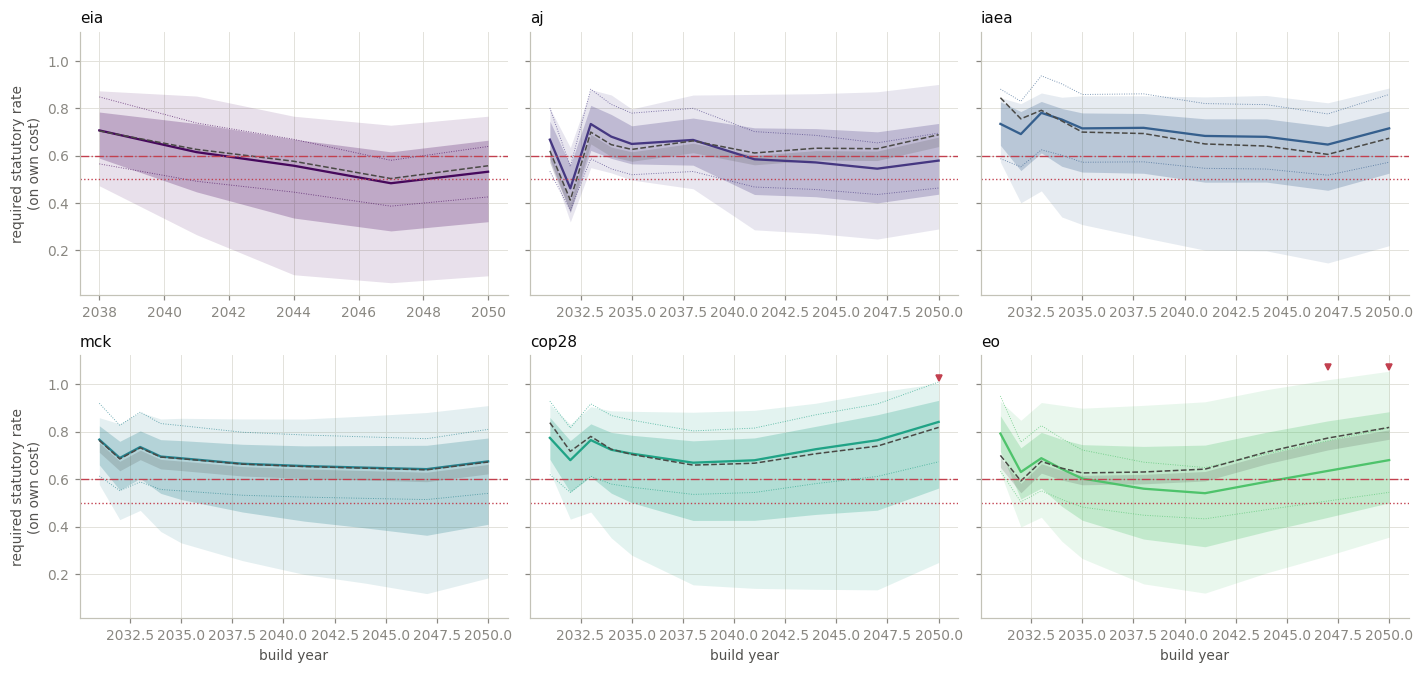

saved -> figures\w31_dollar_fans.png


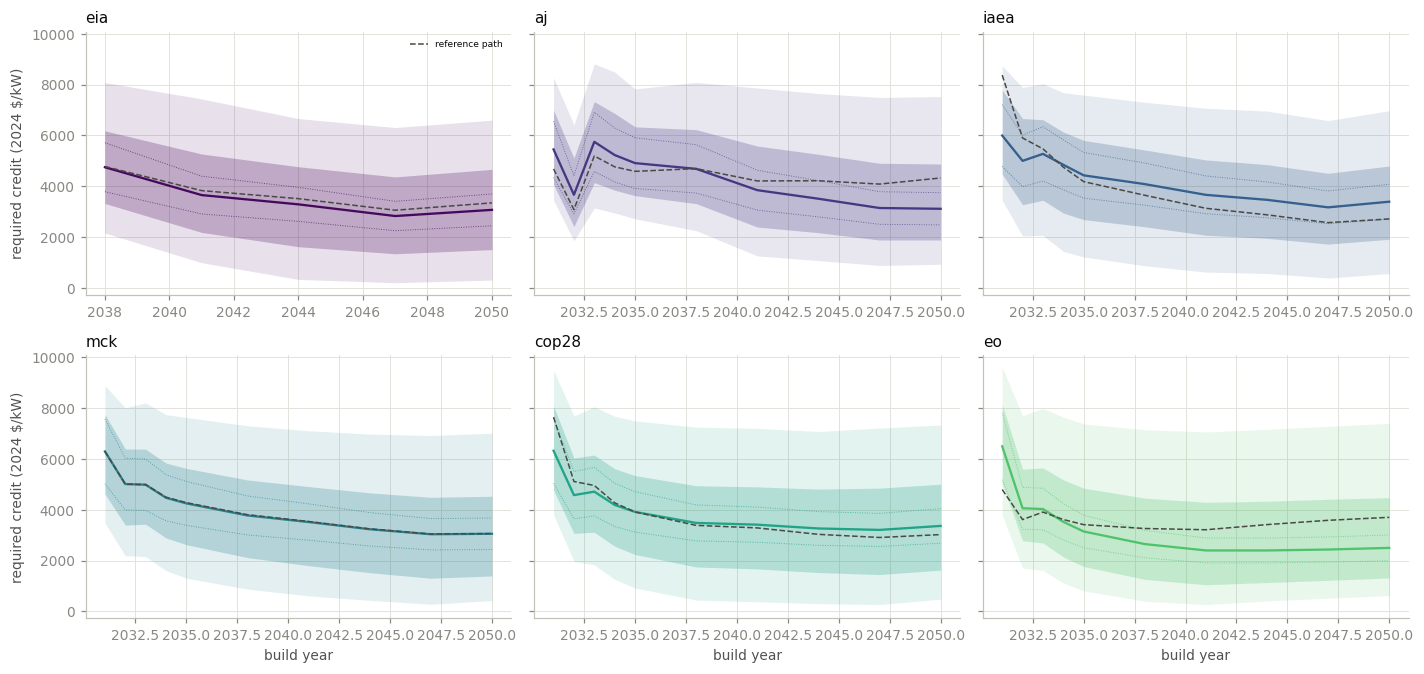

In [5]:
fan_rows = []
BAND = {"base": 1.0, "lo": 0.8, "hi": 1.2}
QS = [5, 25, 50, 75, 95]
for ab in SCHEDULES:
    occ_ref = OCCW[ab][ANCH[ab]["p50"]]
    for band, mult in BAND.items():
        iwm = IW[ab] * mult
        needm = np.maximum(iwm - TOL_SHORT, 0.0) * OCCW[ab]
        for qty, arr, ref in [("rate", iwm, IREF[ab] * mult),
                              ("need_kw", needm, REFC[ab] * mult)]:
            P = np.percentile(arr, QS, axis=0)
            for j, t in enumerate(BUILD_TS[ab]):
                above = round(float(1 - TOPKNOT_PCT[ab][j]) * 100, 1)
                below = round(float(BOTKNOT_PCT[ab][j]) * 100, 1)
                fan_rows.append(dict(schedule=ab, band=band, quantity=qty, year=t,
                                     **{f"p{q:02d}": round(float(P[i, j]), 4)
                                        for i, q in enumerate(QS)},
                                     ref=round(float(ref[j]), 4),
                                     censored=(ab, t) in CENSORED,
                                     above_top_pct=above, below_bot_pct=below,
                                     p95_clamp_pinned=above > 5.0))
u50 = pd.DataFrame(fan_rows)
u50.to_csv(EXPORTS / "u50_requirement_fans.csv", index=False)
base_rate = u50[(u50["band"] == "base") & (u50["quantity"] == "rate")]
print(f"u50: {len(u50)} rows; {int(base_rate['censored'].sum())} censored "
      f"year-cells flagged; {int(base_rate['p95_clamp_pinned'].sum())}/"
      f"{len(base_rate)} cells have a clamp-pinned p95 edge")

# w30: the rate fans with the statutory ceilings and the r03 bracket
fig, axes = plt.subplots(2, 3, figsize=(ps.W3, 6.2), sharey=True)
for ax, ab in zip(axes.flat, SCHEDULES):
    sub = u50[(u50["schedule"] == ab) & (u50["band"] == "base")
              & (u50["quantity"] == "rate")]
    ts = sub["year"].to_numpy()
    ax.fill_between(ts, sub["p05"], sub["p95"], color=ps.SCHED_C[ab], alpha=0.12, lw=0)
    ax.fill_between(ts, sub["p25"], sub["p75"], color=ps.SCHED_C[ab], alpha=0.25, lw=0)
    ax.plot(ts, sub["p50"], color=ps.SCHED_C[ab], lw=1.5)
    for bnd in ["lo", "hi"]:
        sb = u50[(u50["schedule"] == ab) & (u50["band"] == bnd)
                 & (u50["quantity"] == "rate")]
        ax.plot(sb["year"], sb["p50"], color=ps.SCHED_C[ab], lw=0.6, ls=":", alpha=0.7)
    ax.plot(ts, sub["ref"], color=ps.BASE_C, lw=1.0, ls="--")
    if ab in {"aj", "mck", "eo"}:
        ax.fill_between(ts, np.maximum(sub["ref"] - 0.05, 0),
                        np.maximum(sub["ref"] - 0.01, 0),
                        color=ps.BASE_C, alpha=0.18, lw=0)
    for cap, ls in zip(CAPS, [":", "-."]):
        ax.axhline(cap, color=ps.ACCENT["red"], lw=0.9, ls=ls)
    cy = sub[sub["censored"]]["year"]
    if len(cy):
        ax.plot(cy, [ax.get_ylim()[1] * 0.97] * len(cy), "v", ms=4,
                color=ps.ACCENT["red"], clip_on=False)
    ax.set_title(ab)
for ax in axes[1]:
    ax.set_xlabel("build year")
for ax in axes[:, 0]:
    ax.set_ylabel("required statutory rate\n(on own cost)")
fig.tight_layout()
ps.savefig(fig, FIGURES / "w30_rate_fans.png")
plt.show()

# w31: the dollar fans ($/kW)
fig, axes = plt.subplots(2, 3, figsize=(ps.W3, 6.2), sharey=True)
for ax, ab in zip(axes.flat, SCHEDULES):
    sub = u50[(u50["schedule"] == ab) & (u50["band"] == "base")
              & (u50["quantity"] == "need_kw")]
    ts = sub["year"].to_numpy()
    ax.fill_between(ts, sub["p05"], sub["p95"], color=ps.SCHED_C[ab], alpha=0.12, lw=0)
    ax.fill_between(ts, sub["p25"], sub["p75"], color=ps.SCHED_C[ab], alpha=0.25, lw=0)
    ax.plot(ts, sub["p50"], color=ps.SCHED_C[ab], lw=1.5)
    for bnd in ["lo", "hi"]:
        sb = u50[(u50["schedule"] == ab) & (u50["band"] == bnd)
                 & (u50["quantity"] == "need_kw")]
        ax.plot(sb["year"], sb["p50"], color=ps.SCHED_C[ab], lw=0.6, ls=":", alpha=0.7)
    ax.plot(ts, sub["ref"], color=ps.BASE_C, lw=1.0, ls="--", label="reference path")
    ax.set_title(ab)
axes.flat[0].legend(fontsize=6, frameon=False)
for ax in axes[1]:
    ax.set_xlabel("build year")
for ax in axes[:, 0]:
    ax.set_ylabel("required credit (2024 $/kW)")
fig.tight_layout()
ps.savefig(fig, FIGURES / "w31_dollar_fans.png")
plt.show()


**Exhibits 2 and 3 — the credit-feasibility mask and the demonstration
gap.** A statutory investment credit is capped: 50% is today's maximum
(30% base + 10% energy community + 10% domestic content); 60% is the
registered outer bound. A world-year is credit-feasible when its required
rate, less the one-point cushion, fits under the cap. Years above the cap
need a different vehicle — the ARDP model: federal cost-share grants to
first units (TerraPower Natrium and X-energy Xe-100 each received roughly
$2B of 50/50 cost share; NuScale/UAMPS received a $1.35B award; the 1950s
AEC Power Demonstration Reactor Program played the same role for LWRs).
The **demonstration window** is registered as the build years through 2035
(sensitivity: through 2033): above-cap need inside the window is priced as
the demonstration funding requirement; worlds with above-cap need **after**
the window are counted as not credit-feasible — the mask's key output.

Kills: KB1 — "infeasibility concentrates early" must survive the ±20% band;
KB2 — the post-window infeasible share must not move more than 15 points
between the two caps.

**Adjudicated framing (v2.1):** the post-window infeasible share is quoted
only as a **cap × certificate-band range** — the ±20% requirement band
moves it by tens of points, so no single number is honest. KB2 fired for
eia and aj (cap-sensitive); KB1 fired for cop28 at the lo band end (its
demonstration framing is dropped). **eia is N/A throughout this exhibit:**
its build years are 2038–2050, so the demonstration window contains no
eia year — its $0 gap means "the window never intersects the schedule,"
not "no demonstration funding needed." Two pricing caveats: the gap's
p95 is a **lower bound** where the top-knot clamp binds (the 5–17% most
expensive worlds' rates are understated), and kappa's per-anchor spread
puts a ±5% systematic on any single world's priced gap (bounded by G3).
The censored cop28/eo late-year cells understate above-cap shares there —
the infeasible-share direction is conservative.

In [6]:
mask_rows, world_rows, gap_rows = [], [], []
for ab in SCHEDULES:
    for band, mult in BAND.items():
        iwm = IW[ab] * mult
        for cap in CAPS:
            above = iwm > cap + TOL_SHORT          # (10000, T)
            for j, t in enumerate(BUILD_TS[ab]):
                mask_rows.append(dict(schedule=ab, band=band, cap=cap, year=t,
                                      share_above=round(float(above[:, j].mean()), 4),
                                      censored=(ab, t) in CENSORED))
            for wname, wend in [("w2035", W_PRIMARY), ("w2033", W_SENS)]:
                post = [j for j, t in enumerate(BUILD_TS[ab]) if t > wend]
                infeas = np.any(above[:, post], axis=1) if post else np.zeros(10000, bool)
                world_rows.append(dict(schedule=ab, band=band, cap=cap, window=wname,
                                       share_not_credit_feasible=round(float(infeas.mean()), 4)))
                # the demonstration gap: above-cap need inside the window, priced
                win = [j for j, t in enumerate(BUILD_TS[ab]) if t <= wend]
                gap_kw = np.maximum(iwm[:, win] - TOL_SHORT - cap, 0.0) * OCCW[ab][:, win]
                gap_B = gap_kw @ WPRICE[ab][win] if win else np.zeros(10000)
                gq = np.percentile(gap_B, QS)
                gap_rows.append(dict(schedule=ab, band=band, cap=cap, window=wname,
                                     window_applicable=bool(win),
                                     share_needing_demo=round(float((gap_B > 0).mean()), 4),
                                     **{f"gap_p{q:02d}_B": round(float(gq[i]), 3)
                                        for i, q in enumerate(QS)},
                                     gap_mean_B=round(float(gap_B.mean()), 3)))
u51 = pd.DataFrame(mask_rows)
u51w = pd.DataFrame(world_rows)
u51["kind"] = "per_year"
u51w["kind"] = "per_world"
pd.concat([u51, u51w], ignore_index=True).to_csv(
    EXPORTS / "u51_feasibility_mask.csv", index=False)
u52 = pd.DataFrame(gap_rows)
u52.to_csv(EXPORTS / "u52_demonstration_gap.csv", index=False)

# KB1: max in-window share_above >= max post-window share_above, all bands;
# an empty window (eia: build years start 2038) is N/A, not a vacuous pass
kb1_fail, kb1_na = [], []
for ab in SCHEDULES:
    for band in BAND:
        for cap in CAPS:
            sub = u51[(u51["schedule"] == ab) & (u51["band"] == band)
                      & (u51["cap"] == cap)]
            inw_rows = sub[sub["year"] <= W_PRIMARY]["share_above"]
            if not len(inw_rows):
                if ab not in kb1_na:
                    kb1_na.append(ab)
                continue
            inw = inw_rows.max()
            post = sub[sub["year"] > W_PRIMARY]["share_above"].max()
            if post > inw + 1e-12:
                kb1_fail.append((ab, band, cap, round(float(inw), 3), round(float(post), 3)))
VERDICT.append(("kill", "KB1", "PASS-EXC" if not kb1_fail else "KILL-FRAMING",
                (("demonstration framing killed where the post-window above-cap "
                  f"share exceeds the window maximum: {kb1_fail}; " if kb1_fail else
                  "infeasibility concentrates early where the window applies; ")
                 + f"N/A (empty window, framing inapplicable): {kb1_na}")))

# KB2: post-window infeasible share moves <= 15 points between the caps
kb2_fail = []
for ab in SCHEDULES:
    s = u51w[(u51w["schedule"] == ab) & (u51w["band"] == "base")
             & (u51w["window"] == "w2035")].set_index("cap")["share_not_credit_feasible"]
    if abs(float(s.loc[0.50]) - float(s.loc[0.60])) > 0.15:
        kb2_fail.append((ab, round(float(s.loc[0.50]) - float(s.loc[0.60]), 3)))
VERDICT.append(("kill", "KB2", "PASS" if not kb2_fail else "DEMOTE-SENSITIVITY",
                ("cap choice moves the post-window infeasible share <= 15 points "
                 "everywhere" if not kb2_fail else
                 f"cap-sensitive schedules {kb2_fail}: mask reported as a "
                 "cap-sensitivity table")))
VERDICT.append(("kill", "KB3", "PASS",
                "G0 (bills reproduce t08) and G3 (outlay calibrated to t12, "
                "residual <= 7%) re-asserted above"))

# the reportable object: cap x certificate-band RANGES, never one number
rng = (u51w[u51w["window"] == "w2035"]
       .groupby(["schedule", "cap"])["share_not_credit_feasible"]
       .agg(["min", "max"]).round(3))
r60 = rng.xs(0.60, level="cap")
VERDICT.append(("partb", "mask-range", "RANGE-ONLY",
                "post-window infeasible share quoted only as cap x band ranges "
                f"(60% cap, across schedules and band ends: {r60['min'].min():.2f}"
                f"-{r60['max'].max():.2f}); single-number headline retired "
                "(audit B finding 5); eia N/A for the demonstration framing"))
print("not-credit-feasible share, min-max across the +/-20% band (window 2035):")
print(rng.to_string())
print()
print(u52[(u52["band"] == "base") & (u52["window"] == "w2035")]
      [["schedule", "cap", "window_applicable", "share_needing_demo",
        "gap_p50_B", "gap_p95_B"]].to_string(index=False))


not-credit-feasible share, min-max across the +/-20% band (window 2035):
                min    max
schedule cap              
aj       0.5  0.576  1.000
         0.6  0.265  0.868
cop28    0.5  0.699  0.850
         0.6  0.616  0.792
eia      0.5  0.649  1.000
         0.6  0.311  0.904
eo       0.5  0.557  0.858
         0.6  0.406  0.736
iaea     0.5  0.701  0.829
         0.6  0.338  0.779
mck      0.5  0.572  0.794
         0.6  0.276  0.707

schedule  cap  window_applicable  share_needing_demo  gap_p50_B  gap_p95_B
     eia  0.5              False              0.0000      0.000      0.000
     eia  0.6              False              0.0000      0.000      0.000
      aj  0.5               True              1.0000      2.017      5.265
      aj  0.6               True              0.7729      0.851      3.378
    iaea  0.5               True              1.0000     23.737     48.205
    iaea  0.6               True              0.8616     12.999     33.772
     mck  0.5          

saved -> figures\w32_feasibility_mask.png


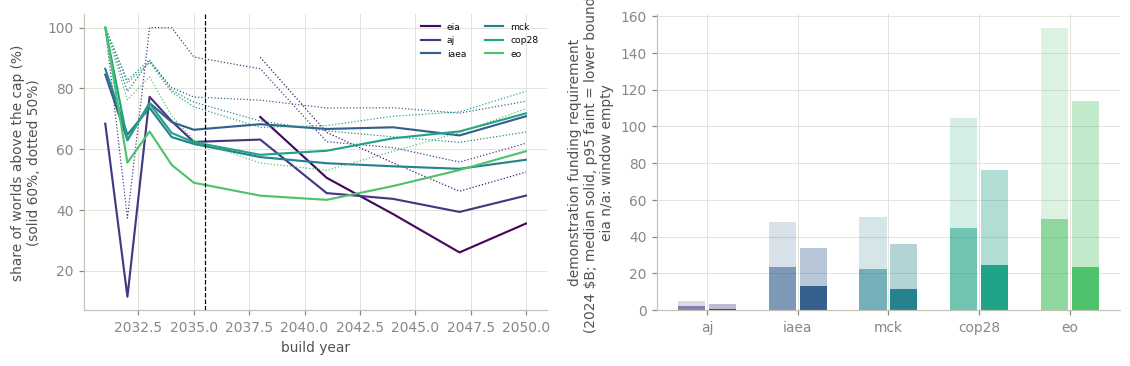

In [7]:
# w32: the mask and the gap
fig, axes = plt.subplots(1, 2, figsize=(ps.W2 * 1.15, 3.4))
for ab in SCHEDULES:
    sub = u51[(u51["schedule"] == ab) & (u51["band"] == "base") & (u51["cap"] == 0.60)]
    axes[0].plot(sub["year"], sub["share_above"] * 100, color=ps.SCHED_C[ab],
                 lw=1.4, label=ab)
    sub5 = u51[(u51["schedule"] == ab) & (u51["band"] == "base") & (u51["cap"] == 0.50)]
    axes[0].plot(sub5["year"], sub5["share_above"] * 100, color=ps.SCHED_C[ab],
                 lw=0.8, ls=":")
axes[0].axvline(W_PRIMARY + 0.5, color="k", lw=0.8, ls="--")
axes[0].set_xlabel("build year")
axes[0].set_ylabel("share of worlds above the cap (%)\n(solid 60%, dotted 50%)")
axes[0].legend(fontsize=6, frameon=False, ncol=2)
# eia is excluded: its build years (2038-2050) never intersect the window
GAP_SCHED = [ab for ab in SCHEDULES if ab != "eia"]
xpos = np.arange(len(GAP_SCHED))
for k_, (cap, off, al) in enumerate([(0.50, -0.17, 0.55), (0.60, 0.17, 1.0)]):
    sub = u52[(u52["band"] == "base") & (u52["window"] == "w2035")
              & (u52["cap"] == cap)].set_index("schedule").reindex(GAP_SCHED)
    axes[1].bar(xpos + off, sub["gap_p95_B"], width=0.3, alpha=al * 0.35,
                color=[ps.SCHED_C[ab] for ab in GAP_SCHED])
    axes[1].bar(xpos + off, sub["gap_p50_B"], width=0.3, alpha=al,
                color=[ps.SCHED_C[ab] for ab in GAP_SCHED])
axes[1].set_xticks(xpos, GAP_SCHED)
axes[1].set_ylabel("demonstration funding requirement\n(2024 $B; median solid, "
                   "p95 faint = lower bound)\neia n/a: window empty")
fig.tight_layout()
ps.savefig(fig, FIGURES / "w32_feasibility_mask.png")
plt.show()


**Exhibit 4 — the dollar menu, with an honestly scoped certificate.**
Delivered share against PV outlay in dollars for the scaled-reference
family. What the model actually certified (v2.1 re-scope, audit B
findings 2–3):

- The rate-ladder runs exist for **three schedules only (aj, mck, eo),
  in one world each** (the p50 anchor world). Their content: the
  headline schedule delivers; one point below the headline still
  delivers; five points below fails. So the **certified** marking covers
  aj/mck/eo at scales in [1 − 0.01/IBAR, 1.0] only; the interval down to
  1 − 0.05/IBAR is the **bracket interior** — "the minimal delivering
  schedule lies in here; the bottom end under-delivers."
- The ladder fed **uniform rate-point decrements, not scaled copies**;
  the scale-family member at the bracket depth differs from the fed
  schedule by up to ~1.8 rate points (computed below) — the certificate
  transfers across that gap only to the cushion's resolution.
- The full-headline point (scale 1.0) was separately fed for all six
  schedules in the fbC feed-back arm: five delivered; **eia delivered
  partially** (delayed start, recovers) — its headline marker is drawn
  open.
- Everywhere else the curve is the **offline coverage criterion**
  (per-world delivery inferred, not run-certified), and the y-axis
  extends one-world delivery certificates to 10,000-world shares via
  that criterion.

The outlay axis is a statutory worst-case bound; the wedge between it
and the dual-priced bill (1.85–2.6x) is printed on the exhibit.

**Exhibit 5 — exposure.** The instrument is allocation-capped: credits are
allocated up to the target build, so the priced outlay is a cap **by
design construction** (an argument, not a run-certified result). What the
runs do show (aj/mck/eo ladders, one world each): delivering rates induce
15–85% over-build (r03 take-up fractions), each extra kilowatt claiming
the credit — so the uncapped version has no every-world bound — and below
the certified band delivered fractions collapse, so the credit is
self-limiting in those tested cases.

aj: decrement-vs-scale family gap up to 1.80 rate points
eo: decrement-vs-scale family gap up to 0.86 rate points
mck: decrement-vs-scale family gap up to 0.66 rate points


saved -> figures\w33_dollar_menu.png


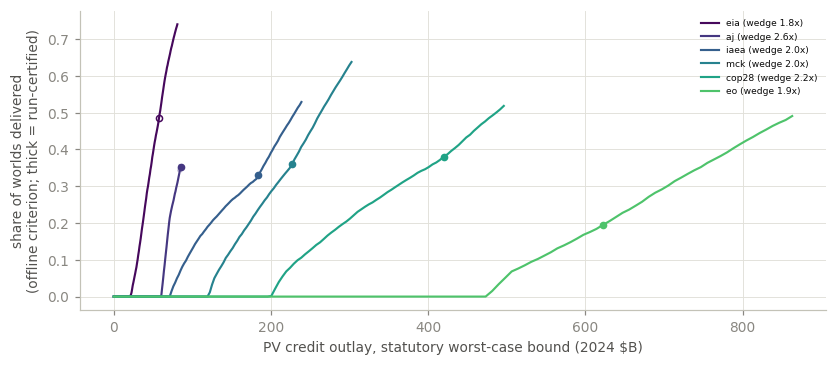

r03 take-up fractions (delivered build / mandate):
           min   max
quantity            
frac_m01  1.15  1.85
frac_m05  0.33  0.95
frac_m10  0.02  0.73
frac_m15  0.00  0.55
frac_p01  1.22  2.72


In [8]:
LADDER = {"aj", "mck", "eo"}          # schedules with a fed rate ladder (r01/r03)
FBC_PARTIAL = {"eia"}                  # fbC full-headline arm: delivered partially
menu_rows = []
for ab in SCHEDULES:
    s_lo = 1 - 0.05 / IBAR[ab]     # the r03 bracket, expressed in scale units
    s_hi = 1 - 0.01 / IBAR[ab]
    s_grid = np.linspace(0.0, 2.6 * P50BILL[ab] / SPREF[ab], 105)
    for s in s_grid:
        if ab in LADDER:
            zone = ("certified" if s_hi <= s <= 1.0 + 1e-9 else
                    "bracket-interior" if s_lo <= s < s_hi else
                    "extrapolated" if s < s_lo else "above-headline")
        else:
            zone = "offline" if s <= 1.0 + 1e-9 else "above-headline"
        menu_rows.append(dict(schedule=ab, s=round(float(s), 4),
                              PV_2024B=round(float(s * SPREF[ab]), 2),
                              capture=round(float((FSTAR[ab] <= s).mean()), 4),
                              zone=zone,
                              bracket_lo=round(s_lo, 4), bracket_hi=round(s_hi, 4),
                              wedge=round(WEDGE[ab], 2)))
u53 = pd.DataFrame(menu_rows)
u53.to_csv(EXPORTS / "u53_dollar_menu.csv", index=False)

# the decrement-vs-scale family gap: the fed rung at the bracket depth is a
# uniform 5-point decrement; the scale member at that depth differs by
# 0.05 x |1 - i_ref(t)/IBAR| rate points (max over build years)
for ab in sorted(LADDER):
    fam_gap = 0.05 * float(np.max(np.abs(1 - IREF[ab] / IBAR[ab])))
    print(f"{ab}: decrement-vs-scale family gap up to {fam_gap * 100:.2f} rate points")

# w33: the menu in dollars (certified overlay only where a ladder was fed)
fig, ax = plt.subplots(figsize=(ps.W1 * 1.2, 3.4))
for ab in SCHEDULES:
    sub = u53[u53["schedule"] == ab]
    ax.plot(sub["PV_2024B"], sub["capture"], color=ps.SCHED_C[ab], lw=1.4,
            label=f"{ab} (wedge {WEDGE[ab]:.1f}x)")
    cert = sub[sub["zone"] == "certified"]
    if len(cert):
        ax.plot(cert["PV_2024B"], cert["capture"], color=ps.SCHED_C[ab],
                lw=3.2, alpha=0.35)
    # full-headline point (fbC arm): open marker where delivery was partial
    head = sub.iloc[(sub["s"] - 1.0).abs().argmin()]
    ax.plot(head["PV_2024B"], head["capture"], "o", ms=4, color=ps.SCHED_C[ab],
            mfc="none" if ab in FBC_PARTIAL else ps.SCHED_C[ab])
ax.set_xlabel("PV credit outlay, statutory worst-case bound (2024 $B)")
ax.set_ylabel("share of worlds delivered\n(offline criterion; thick = run-certified)")
ax.legend(fontsize=6, frameon=False)
fig.tight_layout()
ps.savefig(fig, FIGURES / "w33_dollar_menu.png")
plt.show()

# u54: the exposure summary — take-up fractions and the wedge, from r03
frac_cols = [c for c in r03.columns if c.startswith("frac")]
u54_rows = []
for _, row in r03.iterrows():
    for c in frac_cols:
        if np.isfinite(row[c]):
            u54_rows.append(dict(world=row["world"], quantity=c,
                                 value=round(float(row[c]), 3)))
for ab in SCHEDULES:
    u54_rows.append(dict(world=ab, quantity="wedge_SPREF_over_P50BILL",
                         value=round(WEDGE[ab], 3)))
u54 = pd.DataFrame(u54_rows)
u54.to_csv(EXPORTS / "u54_exposure_summary.csv", index=False)
fr = u54[u54["quantity"].str.startswith("frac")]
print("r03 take-up fractions (delivered build / mandate):")
print(fr.groupby("quantity")["value"].agg(["min", "max"]).round(2).to_string())


## S4 — Part C: the repaired envelope machinery (not yet claimable)

The v1 audit's ruling stands: nothing in this part enters the paper unless
the registered batch passes its gates. The machinery is recomputed here with
every registered repair: schedules exported in $/kW; the headline
comparison is **greedy vs quantile** (set selection), with the unit wedge
stated separately; pricing stays the uncapped worst-case bound (the
statutory ceiling only lowers outlay and never breaks coverage); the
cop28/eo censored knots are disclosed; K1 runs on three seeded holdout
splits; K3 is filter-free; the band path carries the same
zero-reference-year guard as the main path; and a **no-2050 sensitivity**
measures how much of each gain hangs on the terminal year.

An offered $/kW schedule delivers a world exactly when it covers the
world's need in every build year, so the cheapest schedule for a set of
worlds is the set's pointwise-maximum envelope, and the design problem is
a set choice: greedy (candidate optimum), quantile family (envelope of the
k cheapest worlds by f\*), scaled reference (the certified family).

In [9]:
def greedy_path(need, wprice, stop_cost):
    """Greedy max-coverage under envelope cost. Returns (costs, counts, snaps)."""
    nw, T = need.shape
    E = np.zeros(T)
    covered = np.all(need <= 1e-12, axis=1)
    costs, counts = [0.0], [int(covered.sum())]
    snaps = []
    cost = 0.0
    while not covered.all():
        deficit = np.clip(need - E[None, :], 0.0, None)
        inc = deficit @ wprice
        inc[covered] = np.inf
        w = int(np.argmin(inc))
        if not np.isfinite(inc[w]):
            break
        cost += float(inc[w])
        E = np.maximum(E, need[w])
        covered |= np.all(need <= E[None, :] + 1e-12, axis=1)
        costs.append(cost)
        counts.append(int(covered.sum()))
        snaps.append((cost, E.copy()))
        if cost > stop_cost:
            break
    return np.array(costs), np.array(counts), snaps

def capture_at(costs, counts, X, denom):
    j = np.searchsorted(costs, X, side="right") - 1
    return counts[max(j, 0)] / denom

def env_at(snaps, X):
    E = None
    for c, e in snaps:
        if c <= X:
            E = e
        else:
            break
    return E

def quantile_path(need, wprice, fstar_order):
    E = np.zeros(need.shape[1])
    costs = np.empty(len(fstar_order))
    for k, w in enumerate(fstar_order):
        E = np.maximum(E, need[w])
        costs[k] = E @ wprice
    return costs

def fstar_of(need, refc):
    """Thresholds on a reference path, with the zero-reference-year guard
    (the v1 band path lacked it — registered repair 2)."""
    with np.errstate(divide="ignore", invalid="ignore"):
        fr = np.where(need > 0,
                      need / np.where(refc > 0, refc, np.nan)[None, :], 0.0)
    uncov = np.any((need > 0) & (refc[None, :] <= 0), axis=1)
    return np.where(uncov, np.inf,
                    np.nanmax(np.where(need > 0, fr, 0.0), axis=1, initial=0.0))

CONTOUR, CAPTURE, rows73 = {}, [], []
u70_rows = []
for ab in SCHEDULES:
    need = NEED[ab]
    wp = WPRICE[ab]
    occ_ref = OCCW[ab][ANCH[ab]["p50"]]
    Xs = np.array(BUDGET_MULTS) * P50BILL[ab]
    stop = 1.1 * Xs.max()

    g_costs, g_counts, g_snaps = greedy_path(need, wp, stop)
    fo = np.argsort(FSTAR[ab], kind="stable")
    q_costs = quantile_path(need, wp, fo)

    # K1: three seeded holdout splits (registered repair 3)
    splits = []
    for si in range(3):
        rngH = np.random.default_rng(SEED + 7 + si)
        perm = rngH.permutation(10000)
        A, B = perm[:5000], perm[5000:]
        gA = greedy_path(need[A], wp, stop)
        foA = np.argsort(FSTAR[ab][A], kind="stable")
        qA_costs = quantile_path(need[A], wp, foA)
        splits.append((A, B, gA, foA, qA_costs))

    # +/-20% requirement band (K3, filter-free; guard included)
    band = {}
    for tag, mult in [("lo", 0.8), ("hi", 1.2)]:
        need_b = np.maximum(IW[ab] * mult - TOL_SHORT, 0.0) * OCCW[ab]
        fs_b = fstar_of(need_b, REFC[ab] * mult)
        gb = greedy_path(need_b, wp, stop)
        band[tag] = dict(fstar=fs_b, g=gb, spref=float((REFC[ab] * mult) @ wp))

    # no-2050 sensitivity: the whole problem restated without the 2050 row
    m50 = np.array([t != 2050 for t in BUILD_TS[ab]])
    need_n = need[:, m50]
    wp_n = wp[m50]
    refc_n = REFC[ab][m50]
    spref_n = float(refc_n @ wp_n)
    fs_n = fstar_of(need_n, refc_n)
    gn_costs, gn_counts, _ = greedy_path(need_n, wp_n, stop)
    fon = np.argsort(fs_n, kind="stable")
    qn_costs = quantile_path(need_n, wp_n, fon)

    for mult, X in zip(BUDGET_MULTS, Xs):
        cap_g = capture_at(g_costs, g_counts, X, 10000)
        cap_q = np.searchsorted(q_costs, X, side="right") / 10000
        s_aff = X / SPREF[ab]
        cap_s = float((FSTAR[ab] <= s_aff).mean())
        E = env_at(g_snaps, X)
        drops, drops_q = [], []
        for A, B, (gA_costs, gA_counts, gA_snaps), foA, qA_costs in splits:
            capA = capture_at(gA_costs, gA_counts, X, 5000)
            EA = env_at(gA_snaps, X)
            capB = (float(np.all(need[B] <= EA[None, :] + 1e-12, axis=1).mean())
                    if EA is not None else 0.0)
            drops.append(capA - capB)
            kqA = np.searchsorted(qA_costs, X, side="right")
            EqA = np.zeros(need.shape[1])
            for w in foA[:kqA]:
                EqA = np.maximum(EqA, need[A][w])
            capqB = float(np.all(need[B] <= EqA[None, :] + 1e-12, axis=1).mean())
            drops_q.append(kqA / 5000 - capqB)
        cap_g_lo = capture_at(*band["lo"]["g"][:2], X, 10000)
        cap_g_hi = capture_at(*band["hi"]["g"][:2], X, 10000)
        cap_s_lo = float((band["lo"]["fstar"] <= X / band["lo"]["spref"]).mean())
        cap_s_hi = float((band["hi"]["fstar"] <= X / band["hi"]["spref"]).mean())
        if E is not None:
            cov_mask = np.all(need <= E[None, :] + 1e-12, axis=1)
            contam = (float(UPCLAMP[ab][cov_mask].mean()) if cov_mask.any() else 0.0)
            shape_dist = float(np.max(np.abs(E - s_aff * REFC[ab]) / occ_ref))
            for j, t in enumerate(BUILD_TS[ab]):
                u70_rows.append(dict(schedule=ab, mult=mult,
                                     X_2024B=round(float(X), 1), year=t,
                                     envelope_kW=round(float(E[j]), 1),
                                     rate_on_ref=round(float(E[j] / occ_ref[j]), 4),
                                     ref_kW=round(float(REFC[ab][j]), 1),
                                     censored=(ab, t) in CENSORED))
        else:
            contam, shape_dist = np.nan, np.nan
        CAPTURE.append(dict(
            schedule=ab, mult=mult, X_2024B=round(float(X), 1),
            cap_greedy=round(cap_g, 4), cap_quantile=round(cap_q, 4),
            cap_scaled=round(cap_s, 4),
            gain_set=round(cap_g - cap_q, 4),        # HEADLINE: set selection
            gain_shape=round(cap_q - cap_s, 4),      # shape within equal pricing
            gain_total=round(cap_g - cap_s, 4),
            wedge=round(WEDGE[ab], 2),
            holdout_drop_worst=round(float(max(drops)), 4),
            holdout_drop_q_worst=round(float(max(drops_q)), 4),
            cap_greedy_lo=round(cap_g_lo, 4), cap_greedy_hi=round(cap_g_hi, 4),
            cap_scaled_lo=round(cap_s_lo, 4), cap_scaled_hi=round(cap_s_hi, 4),
            gain_sign_lo=int(np.sign(round(cap_g_lo - cap_s_lo, 4))),
            gain_sign_hi=int(np.sign(round(cap_g_hi - cap_s_hi, 4))),
            clamp_contam=round(contam, 4) if np.isfinite(contam) else np.nan,
            shape_dist_ratepts=round(shape_dist, 4) if np.isfinite(shape_dist) else np.nan))
        # no-2050 row
        cap_gn = capture_at(gn_costs, gn_counts, X, 10000)
        cap_qn = np.searchsorted(qn_costs, X, side="right") / 10000
        cap_sn = float((fs_n <= X / spref_n).mean())
        rows73.append(dict(schedule=ab, mult=mult,
                           cap_greedy_no2050=round(cap_gn, 4),
                           cap_quantile_no2050=round(cap_qn, 4),
                           cap_scaled_no2050=round(cap_sn, 4),
                           gain_set_no2050=round(cap_gn - cap_qn, 4),
                           d_cap_greedy=round(cap_gn - cap_g, 4),
                           d_gain_set=round((cap_gn - cap_qn) - (cap_g - cap_q), 4)))
    CONTOUR[ab] = dict(g=(g_costs, g_counts, g_snaps), q=q_costs, fo=fo)
    print(ab, "contours done")

u71 = pd.DataFrame(CAPTURE)
u71.to_csv(EXPORTS / "u71_capture_decomposition.csv", index=False)
u70 = pd.DataFrame(u70_rows)
u70.to_csv(EXPORTS / "u70_contour_schedules_kw.csv", index=False)
u73 = pd.DataFrame(rows73)
u73.to_csv(EXPORTS / "u73_no2050_sensitivity.csv", index=False)
print()
print(u71[["schedule", "mult", "cap_greedy", "cap_quantile", "cap_scaled",
           "gain_set", "gain_shape", "holdout_drop_worst",
           "clamp_contam"]].to_string(index=False))


eia contours done


aj contours done


iaea contours done


mck contours done


cop28 contours done


eo contours done

schedule  mult  cap_greedy  cap_quantile  cap_scaled  gain_set  gain_shape  holdout_drop_worst  clamp_contam
     eia  0.75      0.0707        0.0592      0.0205    0.0115      0.0387              0.0036        0.0000
     eia  1.00      0.1569        0.1367      0.1130    0.0202      0.0237              0.0042        0.0000
     eia  1.25      0.2564        0.2372      0.2312    0.0192      0.0060              0.0028        0.0000
     eia  1.50      0.3505        0.3471      0.3455    0.0034      0.0016              0.0020        0.0000
     eia  2.00      0.5552        0.5531      0.5528    0.0021      0.0003              0.0076        0.0000
      aj  0.75      0.0270        0.0000      0.0000    0.0270      0.0000              0.0050        0.0000
      aj  1.00      0.0824        0.0000      0.0000    0.0824      0.0000              0.0070        0.0000
      aj  1.25      0.1454        0.0011      0.0000    0.1443      0.0011              0.0136        0.0000
 

saved -> figures\w40_contours_kw.png


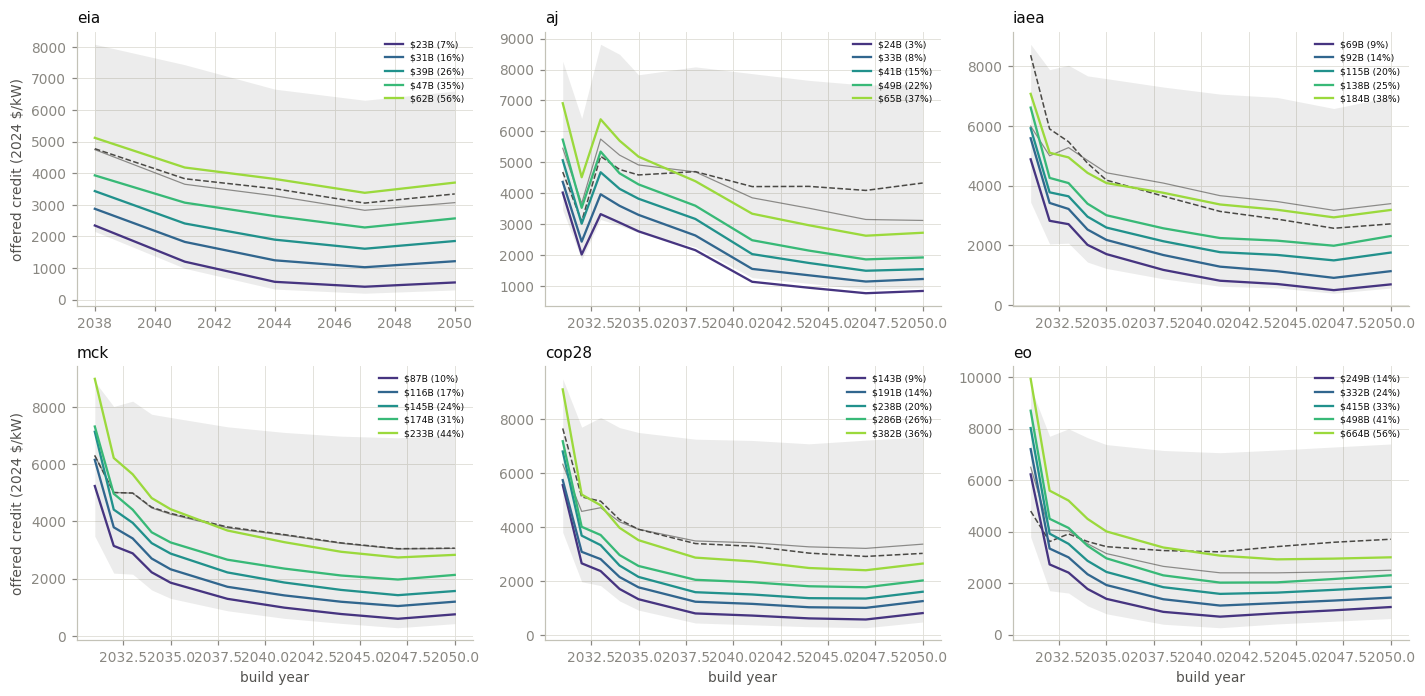

saved -> figures\w41_capture_decomposition.png


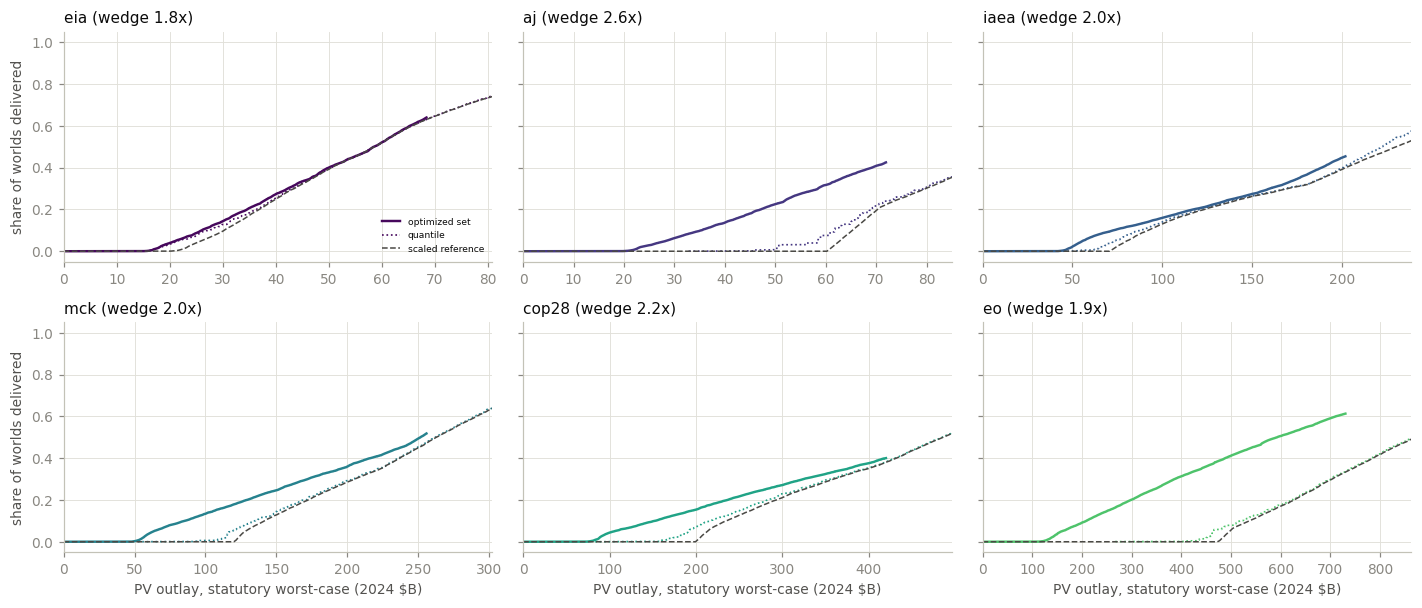

In [10]:
# K1-K4 dispositions (v2 registered forms)
k1_worst = float(u71["holdout_drop_worst"].max())
VERDICT.append(("kill", "K1", "PASS" if k1_worst <= 0.02 else "KILL",
                f"worst greedy holdout drop over 3 seeded splits {k1_worst:.3f} "
                f"(limit 0.02); quantile worst {float(u71['holdout_drop_q_worst'].max()):.3f}"))
k2_best = float(u71["gain_set"].max())
VERDICT.append(("kill", "K2", "PASS" if k2_best >= 0.01 else "DROP-OPTIMIZER",
                f"best greedy-vs-quantile gain {k2_best:.3f} "
                "(< 0.01 means the quantile family is the reported object)"))
k3_bad = u71[(u71["gain_sign_lo"] * np.sign(u71["gain_total"]) < 0)
             | (u71["gain_sign_hi"] * np.sign(u71["gain_total"]) < 0)]
VERDICT.append(("kill", "K3", "PASS" if not len(k3_bad) else "DEMOTE-SI",
                f"{len(k3_bad)} budget rows flip the greedy-vs-scaled gain sign "
                "inside the +/-20% band (filter-free, all rows tested)"))
k4_bad = u71[u71["clamp_contam"] > 0.05]
k4_ceiling = (u71[u71["clamp_contam"] <= 0.05].groupby("schedule")["mult"].max().to_dict())
VERDICT.append(("kill", "K4", "ENFORCED",
                f"{len(k4_bad)} budget rows above the 5% clamp ceiling are not "
                f"reported; largest reportable budget per schedule: {k4_ceiling}"))
worst_2050 = u73.loc[u73["d_gain_set"].abs().idxmax()]
VERDICT.append(("sens", "no-2050", "REPORTED",
                f"dropping the 2050 requirement moves the set-selection gain by at "
                f"most {float(worst_2050['d_gain_set']):+.3f} capture "
                f"({worst_2050['schedule']} {worst_2050['mult']}x); GX1 decides "
                "which table any surviving claim quotes"))

# w40: the contours in $/kW (K4-passing budgets only)
fig, axes = plt.subplots(2, 3, figsize=(ps.W3, 6.4), sharex=False)
CB = plt.cm.viridis(np.linspace(0.15, 0.85, len(BUDGET_MULTS)))
for ax, ab in zip(axes.flat, SCHEDULES):
    fan = u50[(u50["schedule"] == ab) & (u50["band"] == "base")
              & (u50["quantity"] == "need_kw")]
    ts = fan["year"].to_numpy()
    ax.fill_between(ts, fan["p05"], fan["p95"], color=ps.BASE_C, alpha=0.10, lw=0)
    ax.plot(ts, fan["p50"], color=ps.BASE_C, lw=0.8, alpha=0.6)
    ax.plot(ts, fan["ref"], color=ps.BASE_C, lw=1.0, ls="--")
    sub = u71[u71["schedule"] == ab].set_index("mult")
    for c, mult in zip(CB, BUDGET_MULTS):
        e = u70[(u70["schedule"] == ab) & (u70["mult"] == mult)]
        if not len(e) or (np.isfinite(sub.loc[mult, "clamp_contam"])
                          and sub.loc[mult, "clamp_contam"] > 0.05):
            continue
        ax.plot(e["year"], e["envelope_kW"], color=c, lw=1.5,
                label=f"${sub.loc[mult, 'X_2024B']:.0f}B ({sub.loc[mult, 'cap_greedy']:.0%})")
    ax.set_title(ab)
    ax.legend(fontsize=6, loc="upper right", frameon=False)
for ax in axes[1]:
    ax.set_xlabel("build year")
for ax in axes[:, 0]:
    ax.set_ylabel("offered credit (2024 $/kW)")
fig.tight_layout()
ps.savefig(fig, FIGURES / "w40_contours_kw.png")
plt.show()

# w41: capture vs dollars, greedy vs quantile (headline) vs scaled
fig, axes = plt.subplots(2, 3, figsize=(ps.W3, 5.6), sharey=True)
for ax, ab in zip(axes.flat, SCHEDULES):
    g_costs, g_counts, _ = CONTOUR[ab]["g"]
    q_costs = CONTOUR[ab]["q"]
    ax.plot(g_costs, g_counts / 10000, color=ps.SCHED_C[ab], lw=1.6, label="optimized set")
    ax.plot(q_costs, np.arange(1, 10001) / 10000, color=ps.SCHED_C[ab], lw=1.1,
            ls=":", label="quantile")
    s_grid = np.linspace(0, 2.6 * P50BILL[ab] / SPREF[ab], 200)
    ax.plot(s_grid * SPREF[ab], [(FSTAR[ab] <= s).mean() for s in s_grid],
            color=ps.BASE_C, lw=1.0, ls="--", label="scaled reference")
    ax.set_xlim(0, 2.6 * P50BILL[ab])
    ax.set_title(f"{ab} (wedge {WEDGE[ab]:.1f}x)")
axes[0, 0].legend(fontsize=6, frameon=False, loc="lower right")
for ax in axes[1]:
    ax.set_xlabel("PV outlay, statutory worst-case (2024 $B)")
for ax in axes[:, 0]:
    ax.set_ylabel("share of worlds delivered")
fig.tight_layout()
ps.savefig(fig, FIGURES / "w41_capture_decomposition.png")
plt.show()


## S5 — the registered batch: selection, specs, gates (v2.1 re-gated; v2.2 reallocated 2026-09-04)

**The v2.2 allocation (methods.md v2.2, registered before this cell was
re-executed and before any run): 66 launchable runs = 48 ITC-arm + 12
anchors + 6 horizon, reserve retired.** The ITC-arm part emitted here:
**27 envelope feed-back runs** (aj/mck/eo × budgets {1.0, 1.5} × p50 bill
× 3 worlds; eia/iaea/cop28 × 1.5 × 3 worlds — the marginal run was added
at v2.2 so the certificate no longer rests on n = 1 for the three
schedules the minus probe never certified), **7 boundary-depth probes**
(+3 rate points for all six schedules; eo also at +5 — the far edge of
the r03 bracket, on the flattest delivery slope), **14 two-tier hybrid
runs** (6 cap-never-binds at the 0.60 cap, one per schedule; 4 cap-binds
at 0.60 — eia, cop28, eo at +1 and eo at +2 points of post-window excess;
the aj/mck/iaea 0.60 pools are empty — itself reportable: the capped
credit suffices post-window for their entire covered sets; and 4
cap-binds at the **0.50 cap, today's statutory maximum** — aj/mck/iaea/eo,
new at v2.2), **6 extended-horizon runs** (one per schedule). The 12
**anchor-densification runs** (`smr100_{ab}_p25`/`_p75`, mandate arm) are
registered in methods.md v2.2 and materialized by the case-export
notebook (`u82_anchor_spec.csv`), not here: they are not ITC-arm runs and
carry no offered credit path. The v2.1 spec is frozen as
`u80_batch_spec_v21.csv` / `u81_run_schedules_v21.csv`; the drift table
below reports every v2.1 world this re-selection did not reproduce.

**Selection (deterministic).** A world's margin against an envelope is
its worst per-year deficit in rate points on the reference cost basis
(negative = covered with slack). Pools exclude upper-clamped worlds and
any world an ITC cannot serve (offered rate above 0.95 in any year).
Comfortable = covered world nearest the covered pool's median margin;
marginal = margin nearest −1 point; just-uncovered = margin nearest +1
point; depth probes at +3 and +5 points. The certified indeterminacy is
the **r03 bracket** — the true delivery-minimal schedule lies between 1
and 5 points below the headline — so the +1 probes sit inside it and the
depth ladder (+1/+3/+5) brackets where delivery actually stops
(methods.md v2.1; the earlier "0.6–0.7 point model-vs-offline error"
rationale was a category error and is corrected there). **v2.2: every
pick is drawn from its pool minus the worlds already used by any run of
the same schedule** (v2.1 enforced this only for the hybrid block); the
comfortable pick's median target is still computed on the full covered
pool, so the v2.1 picks reproduce unless a collision occurs. Selection
comes from the estimator; the verdict comes only from the runs.

**Gates (v2.1, adjudicated when the batch returns).** "Delivers" = the
run world's shortfall against the mandate trajectory is at most
max(5% of the mandate, 500 MW) in every gate year — the feed-back tier
convention under which the cushion was certified (the earlier
95%-in-every-year rule failed the certifying runs themselves on unit
lumpiness: the deepest delivering rung has a −15.1% year, gap −120.7 MW).

- **GE1 (the certificate, deliver side):** all 24 deliver-side runs
  (9 comfortable, 9 marginal at −1 point, 6 hybrid cap-never-binds)
  deliver. A failure is adjudicated for unit lumpiness first (failure
  gap under one 300 MW unit = convention issue); any true failure fails
  the shaped-schedule certificate.
- **GE2 (the boundary, shortfall side):** the 24 shortfall-side probes
  (9 at +1, 6 at +3, 1 at +5 points, 4 cap-binds at 0.60, 4 cap-binds at
  0.50) are scored as a **measured boundary depth** with the probe
  spacing as its error bar — never as machinery pass/fail. If even the
  +5 probe delivers, the offline criterion is conservative beyond the r03
  bracket: capture numbers survive only as lower bounds and
  contour-shape claims are withdrawn. If the +1 probes fall short, the
  boundary is sharp to the cushion. GE2 is scored on the three-anchor
  margins registered here; a five-anchor re-scoring after the anchor
  runs return is a disclosed secondary read, never a substitute
  (methods.md v2.2).
- **GH1:** all 6 cap-never-binds hybrid worlds deliver. **GH2 (per
  cap, v2.2.1):** the cap-binds probes form a ladder on the cap dimension
  — at 0.60: eia +3, cop28 +1, eo +1 and +2 points of post-window excess
  (n = 4); at 0.50: mck +1, aj +3, iaea +5, eo +5 (n = 4) — depth-scored
  on the three-anchor excess recorded in u80, never re-scored on the
  five-anchor mask or the no-2050 basis (GX1 re-scoring applies to
  `fb_`/`bd_` probes only). Tie-break (v2.2.2): among worlds within 0.005
  of the target excess the earliest post-window binding year wins, because
  a 2050-only bind is exposed to the terminal-year tier tolerance (5% of
  the 2050 mandate = 13–28% of the 2047→2050 increment; cop28 10.2 GW, eo
  15.2 GW) and to GX1; the cop28/eo 0.60 pools have no pre-2050-binding
  world, so those probes bind in 2050 only — disclosed in u80's notes. The 0.50 block has no deliver-side control
  (the 0.60 cap-never-binds runs are the only slack control), so its
  reading is directional; the eia hybrids are pure capped-credit runs
  (eia builds only after the 2035 window). A demonstration, not a
  certification.
- **GA1/GA2/GA3 (anchors, adjudicated post-return):** each new anchor's
  bill reproduces the t08 convention on its own h5 (GA1); the three-anchor
  map predicts each new anchor's bill within ±10% (informative) / ±20%
  (the certificate) (GA2); the signed per-year rate error at each new
  anchor against the prediction written pre-run into `u84` validates the
  batch's probe placement where |error| ≤ 5 rate points (the r03 bracket)
  in every rate-bearing year, and otherwise rides the GE2 depth reads as
  an additional error bar (GA3, v2.2.1).
- **GX1 (per schedule):** an extended-horizon run that sheds at least
  half its schedule's 2047→2050 uptick makes the uptick an
  end-of-horizon artifact for that schedule, whose claims then quote
  the no-2050 basis (u73); no clear verdict keeps the with-2050 basis.
  A GE2 probe whose deficit lies only in shed years is re-scored on the
  chosen basis. Registered run configuration: end year extended (2055
  target), mandate held flat at its 2050 level, monetized-parity (×0.9)
  ITC convention as in the feed-back runs.

**What a pass buys (v2.1 ladder).** GE1 clean → "covered ⇒ delivers"
certified for shaped schedules; the quotable capture is the
**holdout-scored greedy** (in-sample minus the worst K1 split drop,
quoted with that drop as its error bar — the K1 kill stands regardless),
with the quantile family as companion. GE2 supplies the boundary depth.
The hybrid rung is a demonstration of the capped instrument, not an
end-to-end certification. An envelope-run pass certifies the machinery,
not a proposable instrument — 17 of 27 envelope runs (v2.2; 13 of 24 at
v2.1) offer above 60% of the run world's cost in a post-window year; the
hybrids are the instrument test.

In [11]:
def margins(ab, E):
    occ_ref = OCCW[ab][ANCH[ab]["p50"]]
    return np.max((NEED[ab] - E[None, :]) / occ_ref[None, :], axis=1)

def rate_screen_ok(ab, offer):
    """Worlds an ITC can serve at this offer: rate <= RATE_SCREEN each year."""
    return np.all(offer[None, :] / OCCW[ab] <= RATE_SCREEN, axis=1)

def pick_nearest(pool_idx, m, target):
    return int(pool_idx[np.argmin(np.abs(m[pool_idx] - target)
                                  + 1e-12 * pool_idx)])  # tie -> lowest index

spec_rows, sched_rows = [], []
USED = {ab: set() for ab in SCHEDULES}   # v2.2: per-schedule distinctness, every block

def fresh(pool, ab):
    """A pool minus the worlds already used by any run of the same schedule (v2.2)."""
    return np.array([int(x) for x in pool if int(x) not in USED[ab]], dtype=int)

def add_run(run, block, ab, mult, w, offer, expected, gate, margin, note="", cap=np.nan,
            target=np.nan, pool_n=-1):
    occ_w = OCCW[ab][w]
    rates = offer / occ_w
    cap_eff = 0.60 if np.isnan(cap) else cap     # tier split at the run's own cap (v2.2)
    credit = np.minimum(offer, cap_eff * occ_w)
    demo = offer - credit
    assert float(rates.max()) < 1.0, (run, float(rates.max()))
    assert float(rates.max()) <= RATE_SCREEN + 1e-9, (run, float(rates.max()))
    assert int(w) not in USED[ab], (run, int(w), "world reused within schedule")
    USED[ab].add(int(w))
    # v2.2.1 disclosure: the years in which the offer falls short of the world's own need
    short = offer < NEED[ab][w] - 1e-9
    deficit_years = "|".join(str(t) for t, s in zip(BUILD_TS[ab], short) if s)
    spec_rows.append(dict(run=run, block=block, schedule=ab, mult=mult,
                          draw_index=int(w), expected=expected, gate=gate,
                          margin_ratepts=round(float(margin), 4),
                          max_rate_on_world=round(float(rates.max()), 3),
                          cap=cap, target_ratepts=(np.nan if np.isnan(target)
                                                   else round(float(target), 4)),
                          pool_n=int(pool_n), deficit_years=deficit_years, note=note))
    for j, t in enumerate(BUILD_TS[ab]):
        sched_rows.append(dict(run=run, block=block, schedule=ab, year=t,
                               offer_kW=round(float(offer[j]), 1),
                               occ_world_kW=round(float(occ_w[j]), 1),
                               rate_on_world=round(float(rates[j]), 4),
                               credit_tier_kW=round(float(credit[j]), 1),
                               demo_tier_kW=round(float(demo[j]), 1)))

# v2.2: the breadth schedules gain the marginal (-1 pt) run
FB_BLOCKS = ([(ab, m, ["cw", "mg", "ju"]) for ab in ["aj", "mck", "eo"] for m in FB_MULTS]
             + [(ab, 1.5, ["cw", "mg", "ju"]) for ab in ["eia", "iaea", "cop28"]])
ENV = {}
for ab, mult, picks in FB_BLOCKS:
    X = mult * P50BILL[ab]
    E = env_at(CONTOUR[ab]["g"][2], X)
    assert E is not None, (ab, mult)
    ENV[(ab, mult)] = E
    m = margins(ab, E)
    ok = ~UPCLAMP[ab] & rate_screen_ok(ab, E)
    cov_full = np.flatnonzero((m <= 0) & ok)
    med_m = float(np.median(m[cov_full]))       # median target on the FULL covered pool (v2.1 rule)
    cov_pool = fresh(cov_full, ab)
    unc_pool = fresh(np.flatnonzero((m > 0) & ok), ab)
    assert len(cov_pool) > 10 and len(unc_pool) > 10, (ab, mult)
    # probes at the cushion resolution (methods.md v2, amendment 2):
    # marginal = one rate point of slack; just-uncovered = one point short
    sel = {"cw": (pick_nearest(cov_pool, m, med_m), med_m, len(cov_pool)),
           "mg": (pick_nearest(cov_pool, m, -0.01), -0.01, len(cov_pool)),
           "ju": (pick_nearest(unc_pool, m, 0.01), 0.01, len(unc_pool))}
    for tag in picks:
        w, tgt, npool = sel[tag]
        expected = "deliver" if tag in ("cw", "mg") else "shortfall"
        gate = "GE1" if tag in ("cw", "mg") else "GE2"   # deliver side = GE1 (v2.1)
        add_run(f"fb_{ab}_m{int(mult * 100):03d}_{tag}", "envelope", ab, mult,
                w, E, expected, gate, m[w], target=tgt, pool_n=npool)

# boundary-depth probes: +3 points for all six schedules (v2.2; v2.1 had aj/mck/eo),
# +5 for eo (r03 far edge)
BD_TARGETS = {ab: [0.03] for ab in SCHEDULES}
BD_TARGETS["eo"] = [0.03, 0.05]
for ab in SCHEDULES:
    E = ENV[(ab, 1.5)]
    m = margins(ab, E)
    ok = ~UPCLAMP[ab] & rate_screen_ok(ab, E)
    for tg in BD_TARGETS[ab]:
        unc_pool = fresh(np.flatnonzero((m > 0) & ok), ab)
        w = pick_nearest(unc_pool, m, tg)
        add_run(f"bd_{ab}_p{int(tg * 100)}", "boundary", ab, 1.5, w, E,
                "shortfall", "GE2", m[w], target=tg, pool_n=len(unc_pool),
                note=f"depth probe at +{tg * 100:.0f} rate points")

# hybrid runs: window years full envelope, post-window capped credit; worlds
# distinct from every other run world of the schedule. v2.2: all six
# schedules get the cap-never-binds run and a 0.60 cap-binds attempt (the
# aj/mck/iaea pools are empty -> verdict rows, reportable); eo keeps its
# second 0.60 probe at +2 pts; aj/mck/iaea/eo get a cap-binds probe at the
# 0.50 cap (today's statutory maximum) -- the same cb rule at cap 0.50.
# v2.2.1 (review repair 1): the cap-binds probes form a LADDER on the cap dimension —
# 0.60: eia +3, cop28 +1, eo +1/+2; 0.50: mck +1 (pool tops out at +0.024), aj +3,
# iaea +5, eo +5 points of post-window excess. Same cb rule, new targets; the achieved
# excess must sit within 0.005 of its target.
CB60_T = {"eia": 0.03, "aj": 0.01, "iaea": 0.01, "mck": 0.01, "cop28": 0.01, "eo": 0.01}
CB50_T = {"mck": 0.01, "aj": 0.03, "iaea": 0.05, "eo": 0.05}
HY_JOBS = {ab: [("nb", 0.60, "deliver", "GH1", None),
                ("cb", 0.60, "shortfall", "GH2", CB60_T[ab])] for ab in SCHEDULES}
HY_JOBS["eo"].append(("cb2", 0.60, "shortfall", "GH2", 0.02))
for ab, tg in CB50_T.items():
    HY_JOBS[ab].append(("cb50", 0.50, "shortfall", "GH2", tg))
for ab in SCHEDULES:
    mult = 1.5
    E = ENV[(ab, mult)]
    m = margins(ab, E)
    ok = ~UPCLAMP[ab] & rate_screen_ok(ab, E)
    post = np.array([t > W_PRIMARY for t in BUILD_TS[ab]])
    cov = (m <= 0) & ok
    no_window = not np.any(~post)          # eia builds only after 2035: pure capped credit
    for tag, cap, expected, gate, tgt in HY_JOBS[ab]:
        excess = np.max((IW[ab] - TOL_SHORT - cap)[:, post], axis=1)
        if tag == "nb":
            pool = fresh(np.flatnonzero(cov & (excess <= 0)), ab)
        else:
            pool = fresh(np.flatnonzero(cov & (excess > 0)), ab)
        if not len(pool):
            VERDICT.append(("batch", f"hy_{ab}_{tag}", "EMPTY-POOL",
                            f"no covered world in this hybrid pool at cap {cap:.2f}; "
                            "no run emitted (reportable: the capped credit suffices "
                            "post-window for this schedule's covered set)"))
            continue
        if tag == "nb":
            tgt_eff = float(np.median(m[pool]))
            w = pick_nearest(pool, m, tgt_eff)
        else:
            tgt_eff = tgt
            # v2.2.2 tie-break (review N2): among worlds within 0.005 of the target
            # excess, prefer the EARLIEST post-window binding year (a 2050-only bind is
            # exposed to the terminal-year tier tolerance and to GX1); then nearest excess.
            cand = pool[np.abs(excess[pool] - tgt) <= 0.005]
            if not len(cand):
                cand = pool[[int(np.argmin(np.abs(excess[pool] - tgt)))]]
            bind_t = np.array([min([t for t, p, b in zip(BUILD_TS[ab], post,
                                                         (IW[ab][x] - TOL_SHORT - cap) > 0)
                                    if p and b] or [9999]) for x in cand])
            best = cand[bind_t == bind_t.min()]
            w = int(best[np.argmin(np.abs(excess[best] - tgt) + 1e-12 * best)])
            assert abs(float(excess[w]) - tgt) <= 0.005, (ab, tag, float(excess[w]), tgt)
        offer = np.where(post, np.minimum(E, cap * OCCW[ab][w]), E)
        # disclosure (v2.2.1): binding years = post-window years where the cap cuts the
        # offer below the world's need; nb worlds also report their excess at the 0.50 cap
        binds = [t for t, p, b in zip(BUILD_TS[ab], post,
                                      (IW[ab][w] - TOL_SHORT - cap) > 0) if p and b]
        note = (f"post-window cap {cap:.2f} excess {float(excess[w]):+.3f}; "
                f"bind years {'|'.join(map(str, binds)) or 'none'}")
        if tag == "nb":
            ex50 = float(np.max((IW[ab][w] - TOL_SHORT - 0.50)[post]))
            note += f"; excess at 0.50 cap {ex50:+.3f}"
        if no_window:
            note += "; no demonstration window (all build years post-2035): pure capped credit"
        add_run(f"hy_{ab}_{tag}", "hybrid", ab, mult, w, offer, expected,
                gate, m[w], cap=cap, target=tgt_eff, pool_n=len(pool), note=note)

# extended-horizon runs: one per schedule (v2.1; the v2 four-schedule pick
# used a stale exposure ranking — aj is the most 2050-sensitive in u73)
for ab in SCHEDULES:
    case = f"smr100_{ab}_p50"
    up = rate_of(case, 2050) - rate_of(case, 2047)
    spec_rows.append(dict(run=f"hz_{ab}_p50_ext", block="horizon", schedule=ab,
                          mult=np.nan, draw_index=int(ANCH[ab]["p50"]),
                          expected="diagnostic", gate="GX1", margin_ratepts=np.nan,
                          max_rate_on_world=np.nan,
                          note=f"rerun the p50 anchor extended (2055 target, "
                               f"mandate flat at its 2050 level, x0.9 monetized "
                               f"parity); 2047->2050 uptick {up:+.3f} rate pts; "
                               f"artifact if the extended run sheds >= half"))

# v2.2: no reserve (one batch, every slot live). Registered counts:
N_ITC, N_HZ, N_ANCHOR = 48, 6, 12          # anchors live in u82 (case-export notebook)
u80 = pd.DataFrame(spec_rows)
assert len(u80) == N_ITC + N_HZ, (len(u80), u80["block"].value_counts().to_dict())
assert (u80["block"] == "reserve").sum() == 0
live = u80[u80["block"].isin(["envelope", "boundary", "hybrid"])]
assert len(live) == N_ITC, len(live)
assert (live["max_rate_on_world"] < 1.0).all()
assert (live["max_rate_on_world"] <= RATE_SCREEN).all()
# within a schedule, no world serves two runs (v2.2: every block)
for ab_, g_ in live.groupby("schedule"):
    assert g_["draw_index"].is_unique, (ab_, "world reused across runs")
# block order for the casefile: envelope -> boundary -> hybrid -> (anchor) -> horizon LAST
_seq = list(u80["block"])
assert _seq == sorted(_seq, key=["envelope", "boundary", "hybrid", "horizon"].index)
u80.to_csv(EXPORTS / "u80_batch_spec.csv", index=False)
u81 = pd.DataFrame(sched_rows)
u81.to_csv(EXPORTS / "u81_run_schedules.csv", index=False)

# drift table vs the frozen v2.1 spec: every v2.1 run must reappear on the same world
# unless the v2.2 distinctness rule moved it (reported, never silent)
u80_v21 = pd.read_csv(EXPORTS / "u80_batch_spec_v21.csv")
u80_v21 = u80_v21[u80_v21["block"] != "reserve"]
_now = u80.set_index("run")["draw_index"]
drift = []
for _, r in u80_v21.iterrows():
    w_now = int(_now[r["run"]]) if r["run"] in _now.index else None
    if w_now != int(r["draw_index"]):
        drift.append(dict(run=r["run"], world_v21=int(r["draw_index"]), world_v22=w_now))
drift = pd.DataFrame(drift, columns=["run", "world_v21", "world_v22"])
drift.to_csv(EXPORTS / "u83_v21_drift.csv", index=False)
n_cb60 = int(((u80["gate"] == "GH2") & (u80["cap"] == 0.60)).sum())
n_cb50 = int(((u80["gate"] == "GH2") & (u80["cap"] == 0.50)).sum())
n_nb = int((u80["gate"] == "GH1").sum())
VERDICT.append(("batch", "spec", "EMITTED",
                f"v2.2 u80: {len(u80)} rows = {int((u80['block'] == 'envelope').sum())} envelope, "
                f"{int((u80['block'] == 'boundary').sum())} boundary-depth, "
                f"{int((u80['block'] == 'hybrid').sum())} hybrid ({n_nb} cap-never-binds, "
                f"{n_cb60} cap-binds at 0.60, {n_cb50} cap-binds at 0.50), "
                f"{int((u80['block'] == 'horizon').sum())} horizon, 0 reserve; plus "
                f"{N_ANCHOR} p25/p75 anchors registered in u82 (case-export notebook) = "
                f"{len(u80) + N_ANCHOR} launchable runs; every live run's max offered rate "
                f"{float(live['max_rate_on_world'].max()):.3f} <= {RATE_SCREEN}"))
VERDICT.append(("batch", "v21-drift", "NONE" if drift.empty else "REPORTED",
                "all v2.1 run worlds reproduced" if drift.empty else
                f"{len(drift)} v2.1 run(s) moved by the v2.2 distinctness rule: "
                + "; ".join(f"{r.run} {r.world_v21}->{r.world_v22}" for r in drift.itertuples())))
VERDICT.append(("amendment", "v2.2", "REGISTERED",
                "pre-launch reallocation (methods.md v2.2, 2026-09-04): breadth marginal "
                "+ depth + hybrid runs, 0.50-cap cap-binds probes, reserve retired, "
                "p25/p75 anchor densification (GA1/GA2 = one added rung); no threshold or "
                "kill changed; GE2 scored on the three-anchor margins as registered"))
VERDICT.append(("amendment", "v2.2.1", "REGISTERED",
                "adversarial-review repairs (methods.md v2.2.1, 2026-09-04, pre-launch): "
                "cap-binds ladder (0.60: eia +3, cop28 +1, eo +1/+2; 0.50: mck +1, aj +3, "
                "iaea +5, eo +5); GX1 re-scoring restricted to fb_/bd_ probes, GH1/GH2 "
                "scored on the u80 three-anchor excess only; GA3 (per-year rate error at "
                "the new anchors, |err| <= 5 pts validates probe placement) + u84 "
                "predictions written pre-run; u80 gains target/pool_n/deficit_years; eia "
                "hybrids disclosed as pure capped credit; 0.50 block has no slack control "
                "(directional); GA2 +/-10% informative tier"))
VERDICT.append(("amendment", "v2.2.2", "REGISTERED",
                "confirmatory-review repairs (methods.md v2.2.2, 2026-09-04, pre-launch): "
                "cb tie-break = among worlds within 0.005 of the target excess prefer the "
                "earliest post-window binding year, then nearest excess (re-picks eo cb50 "
                "to a pre-2050 bind where available); GX1 pending-gate text restricted to "
                "fb_/bd_; GA3 validates placement to the r03 bracket, not to probe spacing; "
                "2050 tier tolerance disclosed (5% of the 2050 mandate = 13-28% of the "
                "2047->2050 increment; cop28 10.2 GW, eo 15.2 GW)"))
VERDICT.append(("kill", "K1-ladder", "REGISTERED",
                "K1's kill stands regardless of batch outcome: the quotable capture "
                "is the holdout-scored greedy (in-sample minus the worst split "
                "drop, quoted with that drop as its error bar), with the "
                "quantile-family capture as the surviving-family companion"))
VERDICT.append(("repair", "amendment-2-rationale", "CORRECTED",
                "the 0.6-0.7 pt 'model-vs-offline error' cited in amendment 2 was "
                "u71 shape_dist (envelope vs scaled reference — a design-space "
                "quantity, not a prediction error); the certified indeterminacy is "
                "the r03 bracket (4 points); GE2 re-scored one-sided with the "
                "+1/+3/+5 depth ladder (methods.md v2.1)"))
n_ge1 = int((u80["gate"] == "GE1").sum() + (u80["gate"] == "GH1").sum())
n_ge2 = int((u80["gate"] == "GE2").sum() + (u80["gate"] == "GH2").sum())
for g, det in [
    ("GE1", f"the certificate (deliver side): all {n_ge1} deliver-side runs "
            "(comfortable, marginal at -1 pt, hybrid cap-never-binds) deliver "
            "under the tier convention (shortfall <= max(5% of mandate, 500 MW) "
            "every gate year); failures adjudicated for unit lumpiness first; "
            "any true failure fails the shaped-schedule certificate"),
    ("GE2", f"the boundary (shortfall side): the {n_ge2} shortfall-side probes "
            "(+1/+3/+5 rate points, plus the cap-binds pair) scored as a "
            "measured boundary depth with probe spacing as the error bar, never "
            "as machinery pass/fail; +5 delivering => offline criterion "
            "conservative beyond the r03 bracket, contour-shape claims "
            "withdrawn, capture = lower bounds"),
    ("GH1", f"all {n_nb} cap-never-binds hybrid worlds (distinct from other run "
            "worlds) deliver"),
    ("GH2", f"per cap, a LADDER on the cap dimension (v2.2.1): the {n_cb60} cap-binds "
            "probes at 0.60 (eia +3, cop28 +1, eo +1/+2 pts of post-window excess) and "
            f"the {n_cb50} at 0.50 (mck +1, aj +3, iaea +5, eo +5) depth-scored on the "
            "u80 three-anchor excess only (never re-scored on the five-anchor mask or "
            "the no-2050 basis); aj/mck/iaea 0.60 pools empty (reportable: the capped "
            "credit suffices post-window for their covered sets); the 0.50 block has no "
            "slack control (the 0.60 nb runs are the only one) -> directional; eia "
            "hybrids are pure capped credit (no window); a demonstration, not "
            "certification"),
    ("GA1/GA2/GA3", "anchors (post-return): each p25/p75 anchor's bill reproduces the "
            "t08 convention on its own h5 (GA1); the three-anchor map predicts each new "
            "anchor's bill within +/-10% (informative) / +/-20% (the certificate) (GA2); "
            "the signed per-year RATE error at each new anchor vs the u84 prediction, in "
            "points, validates the batch's probe placement to the r03 bracket where "
            "|err| <= 5 pts in every rate-bearing year (NOT to the 2-pt probe spacing: "
            "a GA3 pass does not separate the +1 from the +3 probes), else GE2 depth "
            "reads carry it as an extra error bar (GA3, v2.2.1/v2.2.2); GE2 stays on "
            "the three-anchor margins, "
            "five-anchor re-scoring = disclosed secondary read; GX1 re-scoring applies "
            "to fb_/bd_ probes only"),
    ("GX1", "per schedule: extended run sheds >= half its 2047->2050 uptick => "
            "artifact, that schedule quotes the no-2050 basis (u73); no clear "
            "verdict keeps the with-2050 basis; fb_/bd_ probes with deficits only "
            "in shed years re-scored on the chosen basis (v2.2.1: fb_/bd_ ONLY — "
            "GH1/GH2 are never re-scored)")]:
    VERDICT.append(("gate-pending", g, "PENDING-RUNS", det))
print(u80[u80["block"] != "reserve"].to_string(index=False))


             run    block schedule  mult  draw_index   expected gate  margin_ratepts  max_rate_on_world  cap  target_ratepts  pool_n                           deficit_years                                                                                                                                                                              note
   fb_aj_m100_cw envelope       aj   1.0         608    deliver  GE1         -0.0420              0.660  NaN         -0.0420   824.0                                                                                                                                                                                                                          
   fb_aj_m100_mg envelope       aj   1.0        2695    deliver  GE1         -0.0100              0.700  NaN         -0.0100   824.0                                                                                                                                                                      

### GA registration (v2.2.1): the three-anchor map's predictions at the new anchors

Written BEFORE any run, so GA2 (bills) and GA3 (per-year rates) are
checkable from the spec. For each p25/p75 anchor (selected by the
case-export notebook into `u82`) and each build year: the three-anchor
predicted required rate on the world's own cost, the predicted \$/kW need,
the world's cost and its per-year cost percentile (the anchors are quantiles
of program NPV, not of per-year cost — a review disclosure), the predicted
bill through 2050 (2024 \$B), and the upper-clamp flag.

In [12]:
_u82p = EXPORTS / "u82_anchor_spec.csv"
assert _u82p.exists(), "u82 missing: execute z-ethan/mc/ratedesign_case_export.ipynb first"
u82 = pd.read_csv(_u82p)
assert len(u82) == 12 and set(u82["schedule"]) == set(SCHEDULES)
rows84 = []
for _, r in u82.iterrows():
    ab, w = r["schedule"], int(r["draw_index"])
    assert (ab, w) not in {(s, int(x)) for s, x in zip(u80["schedule"], u80["draw_index"])}
    for j, t in enumerate(BUILD_TS[ab]):
        rows84.append(dict(run=r["run"], schedule=ab, percentile=r["percentile"],
                           draw_index=w, year=t,
                           pred_rate=round(float(IW[ab][w, j]), 4),
                           pred_need_kW=round(float(NEED[ab][w, j]), 1),
                           occ_world_kW=round(float(OCCW[ab][w, j]), 1),
                           occ_pctile_in_year=round(float((OCCW[ab][:, j] < OCCW[ab][w, j]).mean()), 3),
                           pred_bill_2050_2024B=round(float(B2050[ab][w]), 2),
                           upper_clamped=bool(UPCLAMP[ab][w])))
u84 = pd.DataFrame(rows84)
u84.to_csv(EXPORTS / "u84_anchor_predictions.csv", index=False)
VERDICT.append(("gate-pending", "GA3-predictions", "WRITTEN-PRE-RUN",
                f"u84: {u84['run'].nunique()} anchors x build years; predicted bills "
                + ", ".join(f"{r.run} {r.pred_bill_2050_2024B:.1f}" for r in
                            u84.drop_duplicates('run').itertuples())
                + " (2024 $B); rates and per-year cost percentiles per row"))
print(u84.drop_duplicates("run")[["run", "draw_index", "pred_bill_2050_2024B", "upper_clamped"]]
      .to_string(index=False))
print(u84.pivot(index="run", columns="year", values="pred_rate").round(3).to_string())


             run  draw_index  pred_bill_2050_2024B  upper_clamped
  smr100_eia_p25        7498                 16.98          False
  smr100_eia_p75        6540                 47.66          False
   smr100_aj_p25        3569                 20.89          False
   smr100_aj_p75        9504                 40.38          False
 smr100_iaea_p25         516                 68.82          False
 smr100_iaea_p75        7323                152.80          False
  smr100_mck_p25        3229                 59.51          False
  smr100_mck_p75        2237                165.79          False
smr100_cop28_p25        8895                102.89          False
smr100_cop28_p75        1940                294.85          False
   smr100_eo_p25        5003                212.59          False
   smr100_eo_p75        2664                387.26          False
year               2031   2032   2033   2034   2035   2038   2041   2044   2047   2050
run                                                    

saved -> figures\w42_batch_map.png


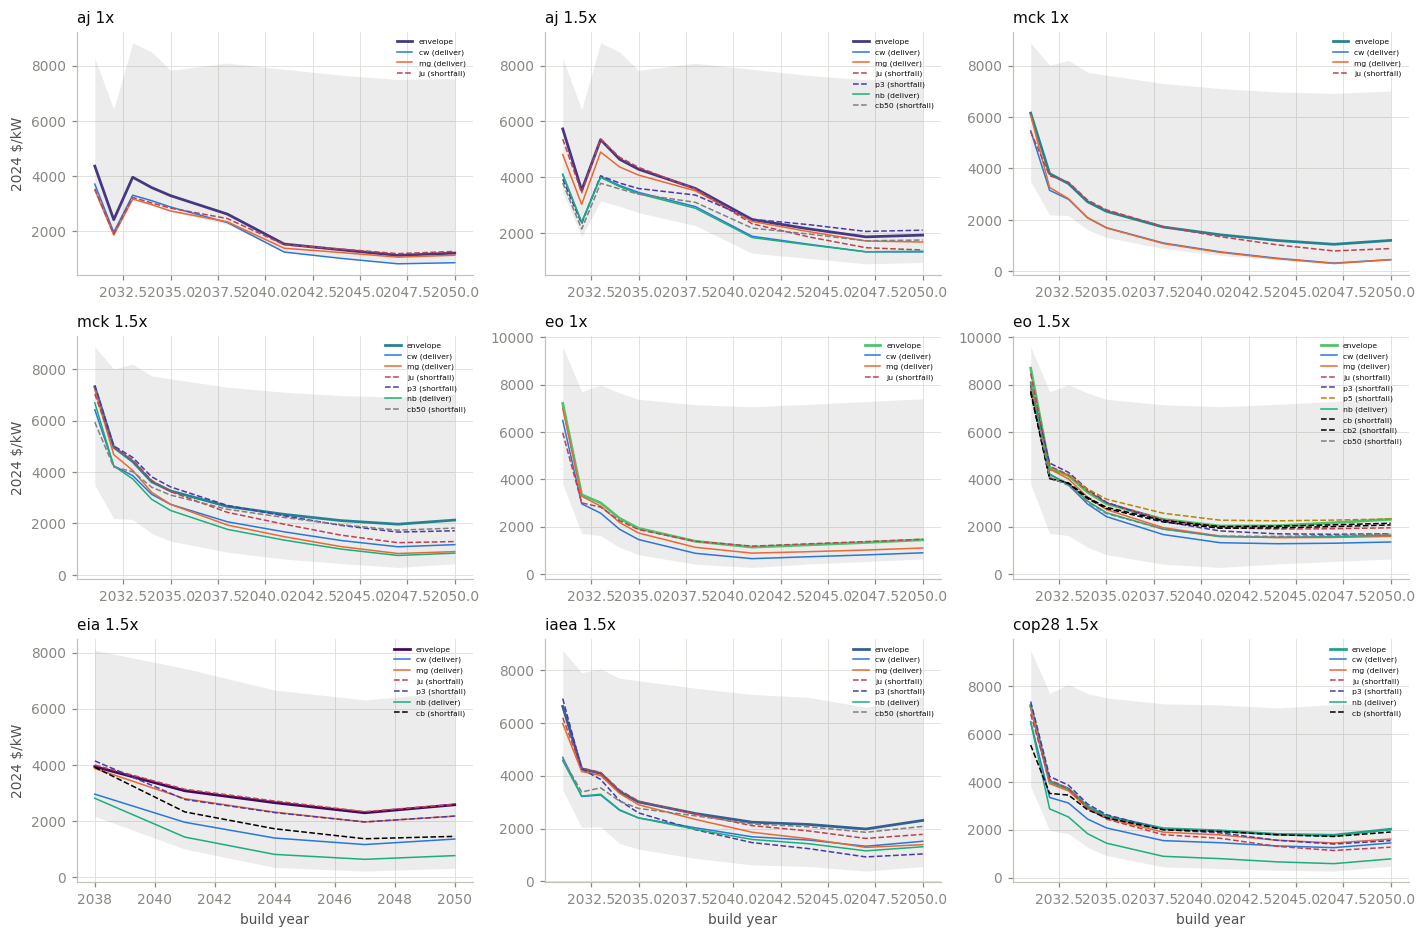

In [13]:
# w42: the batch map — where each run sits against its envelope
panels = [(ab, m) for ab in ["aj", "mck", "eo"] for m in FB_MULTS] \
         + [(ab, 1.5) for ab in ["eia", "iaea", "cop28"]]
fig, axes = plt.subplots(3, 3, figsize=(ps.W3, 8.6))
PCOL = {"cw": ps.ACCENT["blue"], "mg": ps.ACCENT["orange"], "ju": ps.ACCENT["red"],
        "nb": ps.ACCENT["green"], "cb": "k", "cb2": "k", "cb50": "grey",
        "p3": ps.ACCENT["violet"], "p5": ps.ACCENT["gold"]}
for ax, (ab, mult) in zip(axes.flat, panels):
    ts = BUILD_TS[ab]
    fan = u50[(u50["schedule"] == ab) & (u50["band"] == "base")
              & (u50["quantity"] == "need_kw")]
    ax.fill_between(fan["year"], fan["p05"], fan["p95"], color=ps.BASE_C,
                    alpha=0.10, lw=0)
    E = ENV[(ab, mult)]
    ax.plot(ts, E, color=ps.SCHED_C[ab], lw=1.8, label="envelope")
    sub = u80[(u80["schedule"] == ab) & (u80["mult"] == mult)
              & (u80["block"].isin(["envelope", "boundary", "hybrid"]))]
    for _, r in sub.iterrows():
        tag = r["run"].split("_")[-1]
        w = int(r["draw_index"])
        ax.plot(ts, NEED[ab][w], color=PCOL.get(tag, "k"), lw=1.0,
                ls="--" if r["expected"] == "shortfall" else "-",
                label=f"{tag} ({r['expected']})")
    ax.set_title(f"{ab} {mult:.2g}x")
    ax.legend(fontsize=5, frameon=False)
for ax in axes[2]:
    ax.set_xlabel("build year")
for ax in axes[:, 0]:
    ax.set_ylabel("2024 $/kW")
fig.tight_layout()
ps.savefig(fig, FIGURES / "w42_batch_map.png")
plt.show()


## S6 — the verdict

Every gate and kill, dispositioned. The pending gates (GE/GH/GX) are what
the batch adjudicates when it returns; until then, Part B is the paper
section and Part C is a registered design.

In [14]:
u91 = pd.DataFrame(VERDICT, columns=["kind", "name", "result", "detail"])
u91.to_csv(EXPORTS / "u91_verdict.csv", index=False)
print(u91.to_string(index=False))


        kind                  name             result                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          detail
        gate                    G0               PASS                                                                                                                                                                                             

## S7 — paper-facing legended variants (w34–w36; added 2026-09-02)

The paper's Fig 5b/6a/6b embed these instead of w20/w30/w32. Identical
data and geometry — the only changes are complete in-figure legends,
de-jargonned axis labels, and integer year ticks (the analysis originals
explained their encodings in the surrounding markdown, which a composed
paper figure does not carry). The originals stay frozen as the audit
record; the outline's `[FIGS]` ledger row provides for new w34+ numbers.

saved -> figures\w34_rate_fans_paper.png


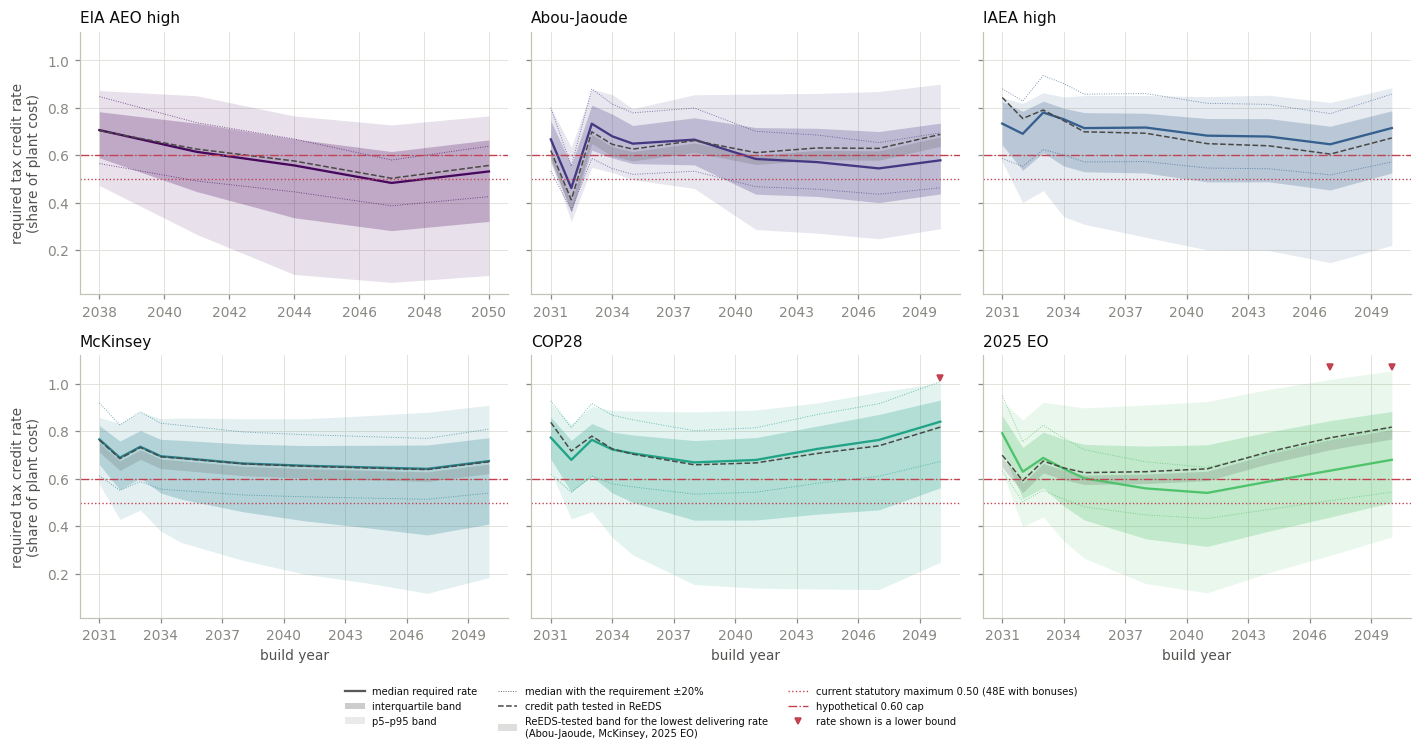

saved -> figures\w35_mask_gap_paper.png


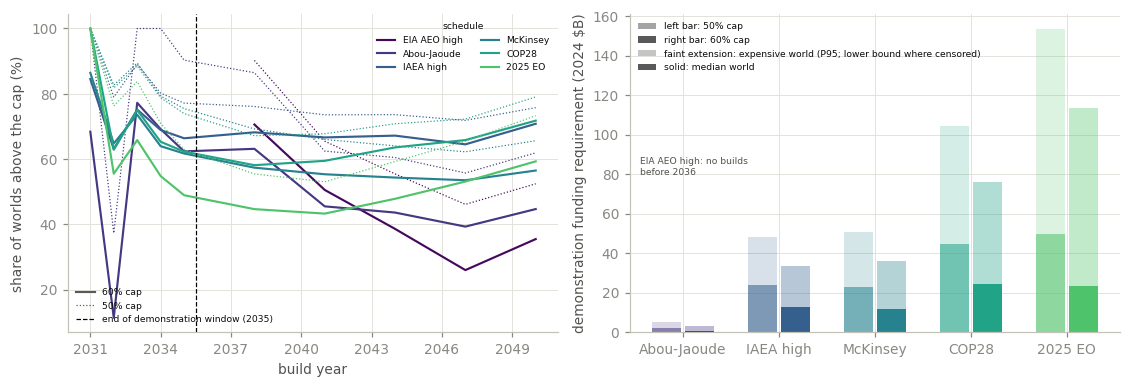

saved -> figures\w36_ci_curves_paper.png


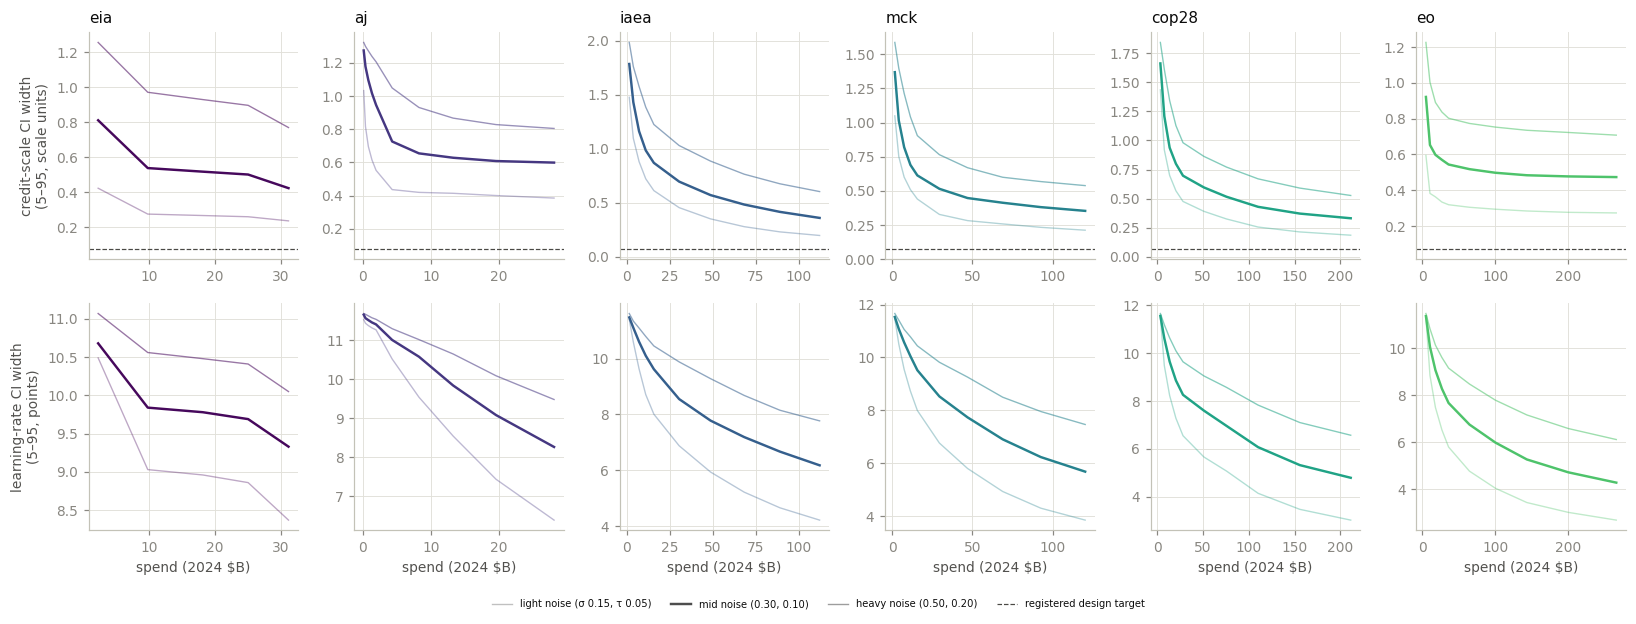

In [15]:
# w34: the rate fans, paper variant (full legend, integer years)
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

fig, axes = plt.subplots(2, 3, figsize=(ps.W3, 6.2), sharey=True)
for ax, ab in zip(axes.flat, SCHEDULES):
    sub = u50[(u50["schedule"] == ab) & (u50["band"] == "base")
              & (u50["quantity"] == "rate")]
    ts = sub["year"].to_numpy()
    ax.fill_between(ts, sub["p05"], sub["p95"], color=ps.SCHED_C[ab], alpha=0.12, lw=0)
    ax.fill_between(ts, sub["p25"], sub["p75"], color=ps.SCHED_C[ab], alpha=0.25, lw=0)
    ax.plot(ts, sub["p50"], color=ps.SCHED_C[ab], lw=1.5)
    for bnd in ["lo", "hi"]:
        sb = u50[(u50["schedule"] == ab) & (u50["band"] == bnd)
                 & (u50["quantity"] == "rate")]
        ax.plot(sb["year"], sb["p50"], color=ps.SCHED_C[ab], lw=0.6, ls=":", alpha=0.7)
    ax.plot(ts, sub["ref"], color=ps.BASE_C, lw=1.0, ls="--")
    if ab in {"aj", "mck", "eo"}:
        ax.fill_between(ts, np.maximum(sub["ref"] - 0.05, 0),
                        np.maximum(sub["ref"] - 0.01, 0),
                        color=ps.BASE_C, alpha=0.18, lw=0)
    for cap, ls in zip(CAPS, [":", "-."]):
        ax.axhline(cap, color=ps.ACCENT["red"], lw=0.9, ls=ls)
    cy = sub[sub["censored"]]["year"]
    if len(cy):
        ax.plot(cy, [ax.get_ylim()[1] * 0.97] * len(cy), "v", ms=4,
                color=ps.ACCENT["red"], clip_on=False)
    ax.set_title(ps.SCHED_SHORT[ab])
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
for ax in axes[1]:
    ax.set_xlabel("build year")
for ax in axes[:, 0]:
    ax.set_ylabel("required tax credit rate\n(share of plant cost)")
GREY = "0.35"
handles = [
    Line2D([], [], color=GREY, lw=1.5, label="median required rate"),
    Patch(facecolor=GREY, alpha=0.30, label="interquartile band"),
    Patch(facecolor=GREY, alpha=0.12, label="p5–p95 band"),
    Line2D([], [], color=GREY, lw=0.6, ls=":",
           label="median with the requirement ±20%"),
    Line2D([], [], color=ps.BASE_C, lw=1.0, ls="--",
           label="credit path tested in ReEDS"),
    Patch(facecolor=ps.BASE_C, alpha=0.18,
          label="ReEDS-tested band for the lowest delivering rate\n(Abou-Jaoude, McKinsey, 2025 EO)"),
    Line2D([], [], color=ps.ACCENT["red"], lw=0.9, ls=":",
           label="current statutory maximum 0.50 (48E with bonuses)"),
    Line2D([], [], color=ps.ACCENT["red"], lw=0.9, ls="-.",
           label="hypothetical 0.60 cap"),
    Line2D([], [], color=ps.ACCENT["red"], ls="", marker="v", ms=4,
           label="rate shown is a lower bound"),
]
fig.tight_layout()
fig.legend(handles=handles, ncol=3, fontsize=6.5, frameon=False,
           loc="upper center", bbox_to_anchor=(0.5, 0.0))
ps.savefig(fig, FIGURES / "w34_rate_fans_paper.png")
plt.show()

# w35: the mask and the gap, paper variant (cap/window/tier legends)
fig, axes = plt.subplots(1, 2, figsize=(ps.W2 * 1.15, 3.6))
for ab in SCHEDULES:
    sub = u51[(u51["schedule"] == ab) & (u51["band"] == "base") & (u51["cap"] == 0.60)]
    axes[0].plot(sub["year"], sub["share_above"] * 100, color=ps.SCHED_C[ab],
                 lw=1.4, label=ps.SCHED_SHORT[ab])
    sub5 = u51[(u51["schedule"] == ab) & (u51["band"] == "base") & (u51["cap"] == 0.50)]
    axes[0].plot(sub5["year"], sub5["share_above"] * 100, color=ps.SCHED_C[ab],
                 lw=0.8, ls=":")
axes[0].axvline(W_PRIMARY + 0.5, color="k", lw=0.8, ls="--")
axes[0].set_xlabel("build year")
axes[0].set_ylabel("share of worlds above the cap (%)")
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
leg_sched = axes[0].legend(fontsize=6, frameon=False, ncol=2, loc="upper right",
                           title="schedule", title_fontsize=6)
axes[0].add_artist(leg_sched)
axes[0].legend(handles=[
    Line2D([], [], color="0.35", lw=1.4, label="60% cap"),
    Line2D([], [], color="0.35", lw=0.8, ls=":", label="50% cap"),
    Line2D([], [], color="k", lw=0.8, ls="--",
           label="end of demonstration window (2035)")],
    fontsize=6, frameon=False, loc="lower left")
GAP_SCHED = [ab for ab in SCHEDULES if ab != "eia"]
xpos = np.arange(len(GAP_SCHED))
for k_, (cap, off, al) in enumerate([(0.50, -0.17, 0.55), (0.60, 0.17, 1.0)]):
    sub = u52[(u52["band"] == "base") & (u52["window"] == "w2035")
              & (u52["cap"] == cap)].set_index("schedule").reindex(GAP_SCHED)
    axes[1].bar(xpos + off, sub["gap_p95_B"], width=0.3, alpha=al * 0.35,
                color=[ps.SCHED_C[ab] for ab in GAP_SCHED])
    axes[1].bar(xpos + off, sub["gap_p50_B"], width=0.3, alpha=al,
                color=[ps.SCHED_C[ab] for ab in GAP_SCHED])
axes[1].set_xticks(xpos, [ps.SCHED_SHORT[ab] for ab in GAP_SCHED])
axes[1].set_ylabel("demonstration funding requirement (2024 $B)")
axes[1].legend(handles=[
    Patch(facecolor="0.35", alpha=0.55, label="left bar: 50% cap"),
    Patch(facecolor="0.35", alpha=1.0, label="right bar: 60% cap"),
    Patch(facecolor="0.35", alpha=0.35,
          label="faint extension: expensive world (P95; lower bound where censored)"),
    Patch(facecolor="0.35", alpha=1.0, label="solid: median world")],
    fontsize=6, frameon=False, loc="upper left")
axes[1].text(0.02, 0.55, "EIA AEO high: no builds\nbefore 2036", transform=axes[1].transAxes,
             fontsize=6, color=ps.MUTED, va="top")
fig.tight_layout()
ps.savefig(fig, FIGURES / "w35_mask_gap_paper.png")
plt.show()

# w36: the CI curves, paper variant (plain labels, full legend)
fig, axes = plt.subplots(2, 6, figsize=(ps.W3 * 1.15, 5.4))
shaded_any = False
for ci, ab in enumerate(SCHEDULES):
    for lv in LEVELS:
        sub = u10[(u10["schedule"] == ab) & (u10["sigma"] == lv[0])
                  & (u10["tau"] == lv[1]) & (u10["k"] > 0)]
        lw = 1.6 if lv == LV_MID else 0.9
        al = LVC[lv]
        axes[0, ci].plot(sub["spend_med"], sub["fstar_w_med"],
                         color=ps.SCHED_C[ab], lw=lw, alpha=al)
        axes[1, ci].plot(sub["spend_med"], sub["lr_w_med"] * 100,
                         color=ps.SCHED_C[ab], lw=lw, alpha=al)
    axes[0, ci].axhline(TGT5[ab], color=ps.BASE_C, lw=0.8, ls="--")
    e = u12[(u12["schedule"] == ab) & (u12["sigma"] == LV_MID[0])].sort_values("year")
    m = u10[(u10["schedule"] == ab) & (u10["sigma"] == LV_MID[0])
            & (u10["tau"] == LV_MID[1]) & (u10["k"] > 0)].sort_values("year")
    starved = e[e["ess_q10"] < ESS_FLOOR]
    if len(starved):
        shaded_any = True
        y0 = int(starved["year"].iloc[0])
        s0 = float(m[m["year"] >= y0]["spend_med"].iloc[0])
        for ax in (axes[0, ci], axes[1, ci]):
            ax.axvspan(s0, float(m["spend_med"].iloc[-1]), color="0.85", zorder=0)
    axes[0, ci].set_title(ab)
    axes[1, ci].set_xlabel("spend (2024 $B)")
axes[0, 0].set_ylabel("credit-scale CI width\n(5–95, scale units)")
axes[1, 0].set_ylabel("learning-rate CI width\n(5–95, points)")
handles36 = [
    Line2D([], [], color="0.3", lw=0.9, alpha=0.35,
           label="light noise (σ 0.15, τ 0.05)"),
    Line2D([], [], color="0.3", lw=1.6, label="mid noise (0.30, 0.10)"),
    Line2D([], [], color="0.3", lw=0.9, alpha=0.55, label="heavy noise (0.50, 0.20)"),
    Line2D([], [], color=ps.BASE_C, lw=0.8, ls="--",
           label="registered design target"),
]
if shaded_any:
    handles36.append(Patch(facecolor="0.85",
                           label="effective sample below 100 worlds"))
fig.tight_layout()
fig.legend(handles=handles36, ncol=len(handles36), fontsize=6.5, frameon=False,
           loc="upper center", bbox_to_anchor=(0.5, 0.0))
ps.savefig(fig, FIGURES / "w36_ci_curves_paper.png")
plt.show()


### w37 — the calibration limit in statutory rate points (paper Fig 5b; added 2026-09-02, Ethan's reading review)

The w36 grid's y axis ("scale units") was not readable in the paper. w37 is the
same u10 data re-denominated: the credit-scale interval width times the reference
path's outlay-weighted average statutory rate (IBAR) is the width of the 90%
interval on the **average statutory rate of the covering credit path** — an exact
conversion, one constant per schedule, so the registered band-5 design target is
5 points in every panel. One panel per schedule on its own linear spend axis
(one column per schedule), three noise levels, the prior (k = 0) at zero
spend; effective-sample shading under the w36 rule (mid-noise q10 ESS < 100 —
never fires). The bottom row (restored the same day, Ethan's ruling) carries
the learning-rate interval width in points on the same per-schedule spend
axes, so the coarse-vs-design contrast is visible in one figure; the geometry
is w36's 2×6 (Ethan's final layout ruling). The rate-point table (both widths)
is exported as u32.

saved -> figures\w37_ci_rate_points_paper.png


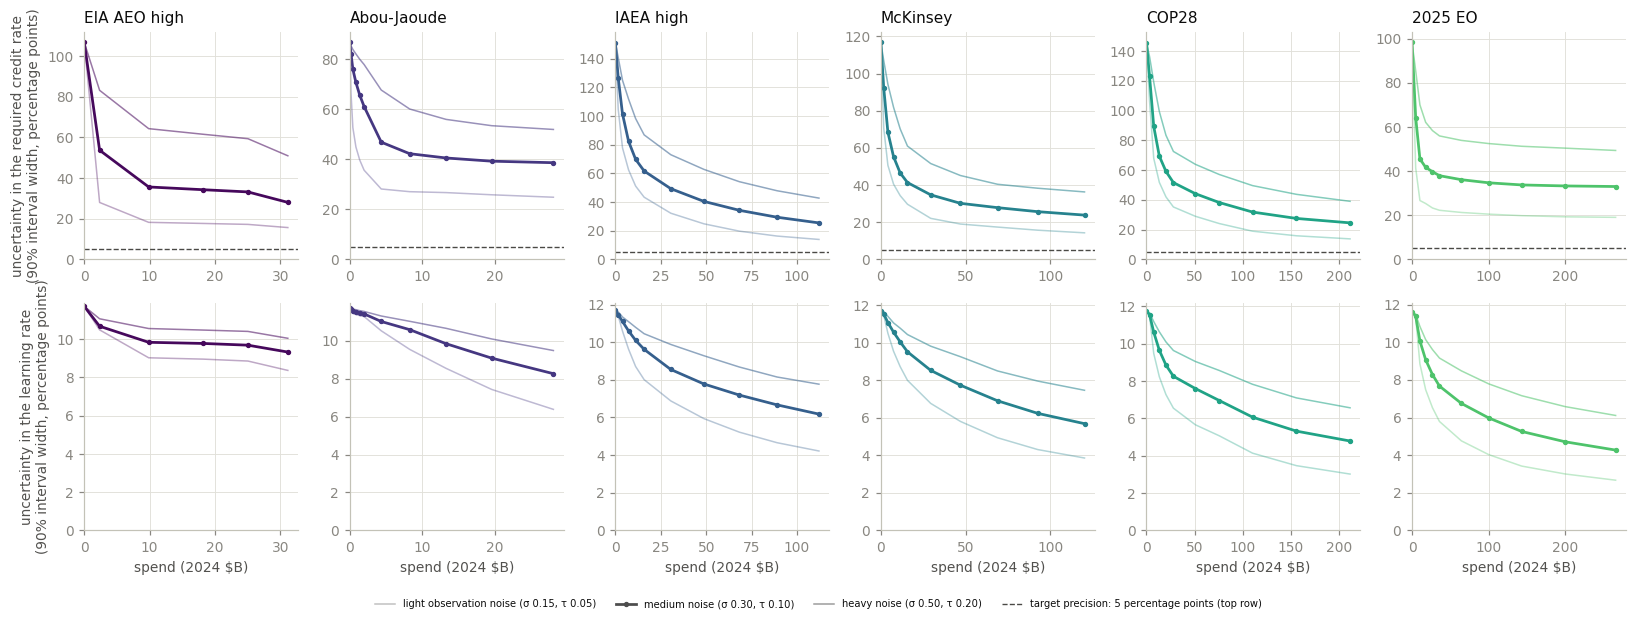

final width, noise (0.15, 0.05): credit rate 14-25 statutory points; learning rate 2.7-8.4 points
final width, noise (0.3, 0.1): credit rate 24-39 statutory points; learning rate 4.3-9.3 points
final width, noise (0.5, 0.2): credit rate 36-52 statutory points; learning rate 6.1-10.1 points
prior width: credit rate 87-151 points (target 5); learning rate 11.6-11.7 points


In [16]:
# w37: the calibration limit in statutory rate points (paper Fig 5b)
# Top row: the required-credit interval (statutory points); bottom row: the
# learning-rate interval (points); one column per schedule (the w36 geometry).
rows32 = []
fig, axes = plt.subplots(2, 6, figsize=(ps.W3 * 1.15, 5.4))
shaded37 = False
for i, ab in enumerate(SCHEDULES):
    ax = axes[0, i]     # credit-rate panel
    axl = axes[1, i]    # learning-rate panel
    for lv in LEVELS:
        sub = u10[(u10["schedule"] == ab) & (u10["sigma"] == lv[0])
                  & (u10["tau"] == lv[1])].sort_values("k")
        pts = sub["fstar_w_med"].to_numpy() * IBAR[ab] * 100.0
        lrp = sub["lr_w_med"].to_numpy() * 100.0
        kw = dict(color=ps.SCHED_C[ab], lw=1.8 if lv == LV_MID else 1.0, alpha=LVC[lv],
                  marker="o", ms=2.5 if lv == LV_MID else 0)
        ax.plot(sub["spend_med"], pts, **kw)
        axl.plot(sub["spend_med"], lrp, **kw)
        for k, yr, sp, w, l in zip(sub["k"], sub["year"], sub["spend_med"], pts, lrp):
            rows32.append(dict(schedule=ab, sigma=lv[0], tau=lv[1], k=int(k),
                               year=int(yr), spend_med_2024B=float(sp),
                               width_pts=round(float(w), 2),
                               lr_width_pts=round(float(l), 2),
                               ibar=round(IBAR[ab], 4)))
    e = u12[(u12["schedule"] == ab) & (u12["sigma"] == LV_MID[0])].sort_values("year")
    m = u10[(u10["schedule"] == ab) & (u10["sigma"] == LV_MID[0])
            & (u10["tau"] == LV_MID[1]) & (u10["k"] > 0)].sort_values("year")
    starved = e[e["ess_q10"] < ESS_FLOOR]
    if len(starved):
        shaded37 = True
        y0 = int(starved["year"].iloc[0])
        s0 = float(m[m["year"] >= y0]["spend_med"].iloc[0])
        for a_ in (ax, axl):
            a_.axvspan(s0, float(m["spend_med"].iloc[-1]), color="0.85", zorder=0)
    ax.axhline(5.0, color=ps.BASE_C, lw=0.9, ls="--")
    ax.set_title(ps.SCHED_SHORT[ab])
    for a_ in (ax, axl):
        a_.set_xlim(0, None)
        a_.set_ylim(0, None)
    axl.set_xlabel("spend (2024 $B)")
for ax in axes[:1, 0]:
    ax.set_ylabel("uncertainty in the required credit rate\n(90% interval width, percentage points)")
for ax in axes[1:, 0]:
    ax.set_ylabel("uncertainty in the learning rate\n(90% interval width, percentage points)")
handles37 = [
    Line2D([], [], color="0.3", lw=1.0, alpha=0.35,
           label="light observation noise (σ 0.15, τ 0.05)"),
    Line2D([], [], color="0.3", lw=1.8, marker="o", ms=2.5, label="medium noise (σ 0.30, τ 0.10)"),
    Line2D([], [], color="0.3", lw=1.0, alpha=0.55, label="heavy noise (σ 0.50, τ 0.20)"),
    Line2D([], [], color=ps.BASE_C, lw=0.9, ls="--",
           label="target precision: 5 percentage points (top row)"),
]
if shaded37:
    handles37.append(Patch(facecolor="0.85", label="effective sample below 100 worlds"))
fig.tight_layout()
fig.legend(handles=handles37, ncol=len(handles37), fontsize=6.5, frameon=False,
           loc="upper center", bbox_to_anchor=(0.5, 0.0))
ps.savefig(fig, FIGURES / "w37_ci_rate_points_paper.png")
plt.show()

u32 = pd.DataFrame(rows32)
u32.to_csv(EXPORTS / "u32_ci_rate_points.csv", index=False)
fin = u32[u32["k"] == u32.groupby(["schedule", "sigma"])["k"].transform("max")]
for lv in LEVELS:
    f = fin[(fin["sigma"] == lv[0]) & (fin["tau"] == lv[1])]
    print(f"final width, noise {lv}: credit rate {f['width_pts'].min():.0f}-{f['width_pts'].max():.0f} statutory points; "
          f"learning rate {f['lr_width_pts'].min():.1f}-{f['lr_width_pts'].max():.1f} points")
pri = u32[(u32["k"] == 0) & (u32["sigma"] == LV_MID[0])]
print(f"prior width: credit rate {pri['width_pts'].min():.0f}-{pri['width_pts'].max():.0f} points (target 5); "
      f"learning rate {pri['lr_width_pts'].min():.1f}-{pri['lr_width_pts'].max():.1f} points")


In [17]:
# manifest (v2 outputs only)
import re
for p in sorted(EXPORTS.glob("u*.csv")) + sorted(FIGURES.glob("w*.png")):
    n = int(re.match(r"[uw](\d+)", p.name).group(1))
    if n >= 20 and n != 90:
        print(f"{p.relative_to(HERE)}  ({p.stat().st_size / 1024:.0f} kB)")


exports\u20_diagnostics.csv  (8 kB)
exports\u30_part_a_restated.csv  (1 kB)
exports\u31_part_a_slopes.csv  (3 kB)
exports\u32_ci_rate_points.csv  (8 kB)
exports\u50_requirement_fans.csv  (29 kB)
exports\u51_feasibility_mask.csv  (17 kB)
exports\u52_demonstration_gap.csv  (5 kB)
exports\u53_dollar_menu.csv  (34 kB)
exports\u54_exposure_summary.csv  (1 kB)
exports\u70_contour_schedules_kw.csv  (13 kB)
exports\u71_capture_decomposition.csv  (4 kB)
exports\u73_no2050_sensitivity.csv  (2 kB)
exports\u80_batch_spec.csv  (7 kB)
exports\u80_batch_spec_v21.csv  (4 kB)
exports\u81_run_schedules.csv  (28 kB)
exports\u81_run_schedules_v21.csv  (20 kB)
exports\u82_anchor_spec.csv  (4 kB)
exports\u83_v21_drift.csv  (0 kB)
exports\u84_anchor_predictions.csv  (8 kB)
exports\u91_verdict.csv  (9 kB)
figures\w20_ci_curves_restated.png  (566 kB)
figures\w21_asymptote.png  (125 kB)
figures\w30_rate_fans.png  (514 kB)
figures\w31_dollar_fans.png  (495 kB)
figures\w32_feasibility_mask.png  (330 kB)
figures\w